<h2 style="font-size: 40px;">1. NuMI</h2>

<h2 style="font-size: 24px;">1.1. Signal selection efficiency analysis</h2>

In [14]:
#BNB, input000.flat.root
#yy-shower truth selection 

#Importing relevant libraries
import numpy
import uproot
import pandas
import hist
import matplotlib.pyplot as plt

#enable this to see all outputs in a cell
#from IPython.core.interactiveshell import InteractiveShell
#InteractiveShell.ast_node_interactivity = "all"

#Opening the relevant ROOT file and tree
file = uproot.open(
    "e:/FYP/medulla_outputs/2_Shower_Selection_flashcut/NuMI_ccpi0ana_icarus_Jkoh1_initial_selection_signal.root:events/NuMI_simulation/signal"
)

#showing all TBranches
file.keys()

#Efficinecy analysis
# --------------------------------------------------------------------------------

#Combining all the relevant cuts into one array for easier analysis
combinedrecocut = file.arrays(["reco_fiducial_cut", "reco_avoid_mystery_zgap","reco_containment_cut","reco_flash_cut","reco_single_muon"
                               ,"reco_no_charged_pions","reco_two_photons","reco_valid_pi0_mass_cut"],library="pd")
combinedrecocut


#Calculating the cumulative efficiency (%) of each cut
flashcut_efficiency = combinedrecocut["reco_flash_cut"].sum() / len(combinedrecocut["reco_flash_cut"]) * 100
print(f"Flash cut efficiency: {flashcut_efficiency:.2f}%")

fiducial_cut_efficiency = combinedrecocut[(combinedrecocut["reco_flash_cut"] == 1) & (combinedrecocut["reco_fiducial_cut"] == 1)].shape[0] / len(combinedrecocut) * 100
print(f"Fiducial cut efficiency: {fiducial_cut_efficiency:.2f}%")

single_muon_efficiency = combinedrecocut[(combinedrecocut["reco_flash_cut"] == 1) & (combinedrecocut["reco_fiducial_cut"] == 1) & (combinedrecocut["reco_single_muon"] == 1)].shape[0] / len(combinedrecocut) * 100
print(f"Single muon cut efficiency: {single_muon_efficiency:.2f}%")

no_charged_pions_efficiency = combinedrecocut[(combinedrecocut["reco_flash_cut"] == 1) & (combinedrecocut["reco_fiducial_cut"] == 1) & (combinedrecocut["reco_single_muon"] == 1) & (combinedrecocut["reco_no_charged_pions"] == 1)].shape[0] / len(combinedrecocut) * 100
print(f"No charged pions cut efficiency: {no_charged_pions_efficiency:.2f}%")

two_photons_efficiency = combinedrecocut[(combinedrecocut["reco_flash_cut"] == 1) & (combinedrecocut["reco_fiducial_cut"] == 1) & (combinedrecocut["reco_single_muon"] == 1) & (combinedrecocut["reco_no_charged_pions"] == 1) & (combinedrecocut["reco_two_photons"] == 1)].shape[0] / len(combinedrecocut) * 100
print(f"Two photons cut efficiency: {two_photons_efficiency:.2f}%")

valid_pi0_mass_cut_efficiency = combinedrecocut[(combinedrecocut["reco_flash_cut"] == 1) & (combinedrecocut["reco_fiducial_cut"] == 1) & (combinedrecocut["reco_single_muon"] == 1) & (combinedrecocut["reco_no_charged_pions"] == 1) & (combinedrecocut["reco_two_photons"] == 1) & (combinedrecocut["reco_valid_pi0_mass_cut"] == 1)].shape[0] / len(combinedrecocut) * 100
print(f"Valid pi0 mass cut efficiency: {valid_pi0_mass_cut_efficiency:.2f}%")

Flash cut efficiency: 95.36%
Fiducial cut efficiency: 93.66%
Single muon cut efficiency: 88.55%
No charged pions cut efficiency: 78.09%
Two photons cut efficiency: 65.11%
Valid pi0 mass cut efficiency: 62.99%


<h2 style="font-size: 24px;">1.1. Reco selection purity analysis</h2>

In [19]:
#BNB, input000.flat.root
#yy-shower truth selection 

#Importing relevant libraries
import numpy
import uproot
import pandas
import hist
import matplotlib.pyplot as plt

#enable this to see all outputs in a cell
#from IPython.core.interactiveshell import InteractiveShell
#InteractiveShell.ast_node_interactivity = "all"

#Opening the relevant ROOT file and tree
file = uproot.open(
    "e:/FYP/medulla_outputs/2_Shower_Selection_flashcut/NuMI_ccpi0ana_icarus_Jkoh1_initial_selection.root:events/NuMI_simulation/Purity_all_interactions;2"
)

#showing all TBranches
file.keys()

#Purity analysis
# --------------------------------------------------------------------------------

#Combining all the relevant cuts into one array for easier analysis
combinedpurity = file.arrays(["reco_fiducial_cut", "reco_avoid_mystery_zgap","reco_flash_cut","reco_single_muon"
                               ,"reco_no_charged_pions","reco_two_photons","reco_valid_pi0_mass_cut"
                               ,"true_fiducial_cut","true_iscc","true_isnumu","true_neutrino","true_no_charged_pions"
                               ,"true_single_muon","true_single_pi0","true_avoid_mystery_zgap"],library="pd")
combinedpurity

#Calculating the cumulative purity (%) of each reco cut

#nocut purity (i.e. purity of all reconstructed interactions that pass the flash cut, without any other cuts)
nocut_purity = len(selected_reco) / len(combinedpurity) * 100
print(f"No cut purity: {nocut_purity:.2f}%")

#flash cut purity (i.e. purity of all reconstructed interactions that pass the flash cut)
flashcut_reco = combinedpurity[combinedpurity["reco_flash_cut"] == 1]
flashcut_purity = combinedpurity[(combinedpurity["reco_flash_cut"] == 1) 
                                 & (combinedpurity["true_fiducial_cut"] == 1)
                                 & (combinedpurity["true_iscc"] == 1)
                                 & (combinedpurity["true_isnumu"] == 1)
                                 & (combinedpurity["true_neutrino"] == 1)
                                 & (combinedpurity["true_no_charged_pions"] == 1)
                                 & (combinedpurity["true_single_muon"] == 1)
                                 & (combinedpurity["true_single_pi0"] == 1)
                                 & (combinedpurity["true_avoid_mystery_zgap"] == 1)].shape[0] / flashcut_reco.shape[0] * 100
print(f"Flash cut purity: {flashcut_purity:.2f}%")

#fiducial cut purity (i.e. purity of all reconstructed interactions that pass the flash cut and fiducial cut)
fiducial_cut_reco = combinedpurity[(combinedpurity["reco_flash_cut"] == 1) & (combinedpurity["reco_fiducial_cut"] == 1)]
fiducial_cut_purity = combinedpurity[(combinedpurity["reco_flash_cut"] == 1) 
                                    & (combinedpurity["reco_fiducial_cut"] == 1)
                                    & (combinedpurity["true_fiducial_cut"] == 1)
                                    & (combinedpurity["true_iscc"] == 1)
                                    & (combinedpurity["true_isnumu"] == 1)
                                    & (combinedpurity["true_neutrino"] == 1)
                                    & (combinedpurity["true_no_charged_pions"] == 1)
                                    & (combinedpurity["true_single_muon"] == 1)
                                    & (combinedpurity["true_single_pi0"] == 1)
                                    & (combinedpurity["true_avoid_mystery_zgap"] == 1)].shape[0] / fiducial_cut_reco.shape[0] * 100
print(f"Fiducial cut purity: {fiducial_cut_purity:.2f}%")

#single muon cut purity (i.e. purity of all reconstructed interactions that pass the flash cut, fiducial cut and single muon cut)
single_muon_cut_reco = combinedpurity[(combinedpurity["reco_flash_cut"] == 1) & (combinedpurity["reco_fiducial_cut"] == 1) & (combinedpurity["reco_single_muon"] == 1)]
single_muon_cut_purity = combinedpurity[(combinedpurity["reco_flash_cut"] == 1) 
                                      & (combinedpurity["reco_fiducial_cut"] == 1)
                                      & (combinedpurity["reco_single_muon"] == 1)
                                      & (combinedpurity["true_fiducial_cut"] == 1)
                                      & (combinedpurity["true_iscc"] == 1)
                                      & (combinedpurity["true_isnumu"] == 1)
                                      & (combinedpurity["true_neutrino"] == 1)
                                      & (combinedpurity["true_no_charged_pions"] == 1)
                                      & (combinedpurity["true_single_muon"] == 1)
                                      & (combinedpurity["true_single_pi0"] == 1)
                                      & (combinedpurity["true_avoid_mystery_zgap"] == 1)].shape[0] / single_muon_cut_reco.shape[0] * 100
print(f"Single muon cut purity: {single_muon_cut_purity:.2f}%")

#no charged pions cut purity (i.e. purity of all reconstructed interactions that pass the flash cut, fiducial cut, single muon cut and no charged pions cut)
no_charged_pions_cut_reco = combinedpurity[(combinedpurity["reco_flash_cut"] == 1) & (combinedpurity["reco_fiducial_cut"] == 1) & (combinedpurity["reco_single_muon"] == 1) & (combinedpurity["reco_no_charged_pions"] == 1)]
no_charged_pions_cut_purity = combinedpurity[(combinedpurity["reco_flash_cut"] == 1) 
                                            & (combinedpurity["reco_fiducial_cut"] == 1)
                                            & (combinedpurity["reco_single_muon"] == 1)
                                            & (combinedpurity["reco_no_charged_pions"] == 1)
                                            & (combinedpurity["true_fiducial_cut"] == 1)
                                            & (combinedpurity["true_iscc"] == 1)
                                            & (combinedpurity["true_isnumu"] == 1)
                                            & (combinedpurity["true_neutrino"] == 1)
                                            & (combinedpurity["true_no_charged_pions"] == 1)
                                            & (combinedpurity["true_single_muon"] == 1)
                                            & (combinedpurity["true_single_pi0"] == 1)
                                            & (combinedpurity["true_avoid_mystery_zgap"] == 1)].shape[0] / no_charged_pions_cut_reco.shape[0] * 100
print(f"No charged pions cut purity: {no_charged_pions_cut_purity:.2f}%")

#two photons cut purity (i.e. purity of all reconstructed interactions that pass the flash cut, fiducial cut, single muon cut, no charged pions cut and two photons cut)
two_photons_cut_reco = combinedpurity[(combinedpurity["reco_flash_cut"] == 1) & (combinedpurity["reco_fiducial_cut"] == 1) & (combinedpurity["reco_single_muon"] == 1) & (combinedpurity["reco_no_charged_pions"] == 1) & (combinedpurity["reco_two_photons"] == 1)]
two_photons_cut_purity = combinedpurity[(combinedpurity["reco_flash_cut"] == 1) 
                                      & (combinedpurity["reco_fiducial_cut"] == 1)
                                      & (combinedpurity["reco_single_muon"] == 1)
                                      & (combinedpurity["reco_no_charged_pions"] == 1)
                                      & (combinedpurity["reco_two_photons"] == 1)
                                      & (combinedpurity["true_fiducial_cut"] == 1)
                                      & (combinedpurity["true_iscc"] == 1)
                                      & (combinedpurity["true_isnumu"] == 1)
                                      & (combinedpurity["true_neutrino"] == 1)
                                      & (combinedpurity["true_no_charged_pions"] == 1)
                                      & (combinedpurity["true_single_muon"] == 1)
                                      & (combinedpurity["true_single_pi0"] == 1)
                                      & (combinedpurity["true_avoid_mystery_zgap"] == 1)].shape[0] / two_photons_cut_reco.shape[0] * 100
print(f"Two photons cut purity: {two_photons_cut_purity:.2f}%")

#valid pi0 mass cut purity (i.e. purity of all reconstructed interactions that pass the flash cut, fiducial cut, single muon cut, no charged pions cut, two photons cut and valid pi0 mass cut)
valid_pi0_mass_cut_reco = combinedpurity[(combinedpurity["reco_flash_cut"] == 1) & (combinedpurity["reco_fiducial_cut"] == 1) & (combinedpurity["reco_single_muon"] == 1) & (combinedpurity["reco_no_charged_pions"] == 1) & (combinedpurity["reco_two_photons"] == 1) & (combinedpurity["reco_valid_pi0_mass_cut"] == 1)]
valid_pi0_mass_cut_purity = combinedpurity[(combinedpurity["reco_flash_cut"] == 1) 
                                        & (combinedpurity["reco_fiducial_cut"] == 1)
                                        & (combinedpurity["reco_single_muon"] == 1)
                                        & (combinedpurity["reco_no_charged_pions"] == 1)
                                        & (combinedpurity["reco_two_photons"] == 1)
                                        & (combinedpurity["reco_valid_pi0_mass_cut"] == 1)
                                        & (combinedpurity["true_fiducial_cut"] == 1)
                                        & (combinedpurity["true_iscc"] == 1)
                                        & (combinedpurity["true_isnumu"] == 1)
                                        & (combinedpurity["true_neutrino"] == 1)
                                        & (combinedpurity["true_no_charged_pions"] == 1)
                                        & (combinedpurity["true_single_muon"] == 1)
                                        & (combinedpurity["true_single_pi0"] == 1)
                                        & (combinedpurity["true_avoid_mystery_zgap"] == 1)].shape[0] / valid_pi0_mass_cut_reco.shape[0] * 100
print(f"Valid pi0 mass cut purity: {valid_pi0_mass_cut_purity:.2f}%")
                                                                  
                                                        


No cut purity: 0.05%
Flash cut purity: 1.50%
Fiducial cut purity: 3.07%
Single muon cut purity: 4.87%
No charged pions cut purity: 5.57%
Two photons cut purity: 59.56%
Valid pi0 mass cut purity: 63.33%


<h2 style="font-size: 24px;">1.3. Selected selection reconstructed neutral pion mass analysis</h2>

Number of cosmic interactions and percentage: 31 out of 3902 (0.79%)
Number of 1mu0pi1pi0 CC neutrinointeractions and percentage: 2515 out of 3902 (64.45%)
Number of 1mu0pi2+pi0 CC neutrino interactions and percentage: 27 out of 3902 (0.69%)
Number of 1muNpiXpi0 CC neutrino interactions and percentage: 344 out of 3902 (8.82%)
Number of 0muNpi0 NC neutrino interactions and percentage: 95 out of 3902 (2.43%)
Number of other neutrino interactions and percentage: 890 out of 3902 (22.81%)
Crystal Ball fit successful!

===== Crystal Ball Fit Results =====
Fitted mean (μ): 132.7380 MeV/c²
Fitted sigma (σ): 11.9468 MeV/c²
Fitted alpha (α): 1.0376
Fitted power n: 1.8499
Fitted amplitude: 922.4

True π⁰ mass (PDG): 134.9768 MeV/c²
Multiplicative correction factor (μ / true π⁰ mass): 0.983414



C:\Users\Jordon Koh\AppData\Local\Temp\ipykernel_18172\3465406487.py:82: RuntimeWarning: divide by zero encountered in power
  f = np.where(t > -abs_alpha, np.exp(-0.5 * t ** 2), A * (B - t) ** (-n))
C:\Users\Jordon Koh\AppData\Local\Temp\ipykernel_18172\3465406487.py:82: RuntimeWarning: invalid value encountered in power
  f = np.where(t > -abs_alpha, np.exp(-0.5 * t ** 2), A * (B - t) ** (-n))
C:\Users\Jordon Koh\AppData\Local\Temp\ipykernel_18172\3465406487.py:80: RuntimeWarning: invalid value encountered in scalar power
  A = (n / abs_alpha) ** n * np.exp(-0.5 * abs_alpha ** 2)


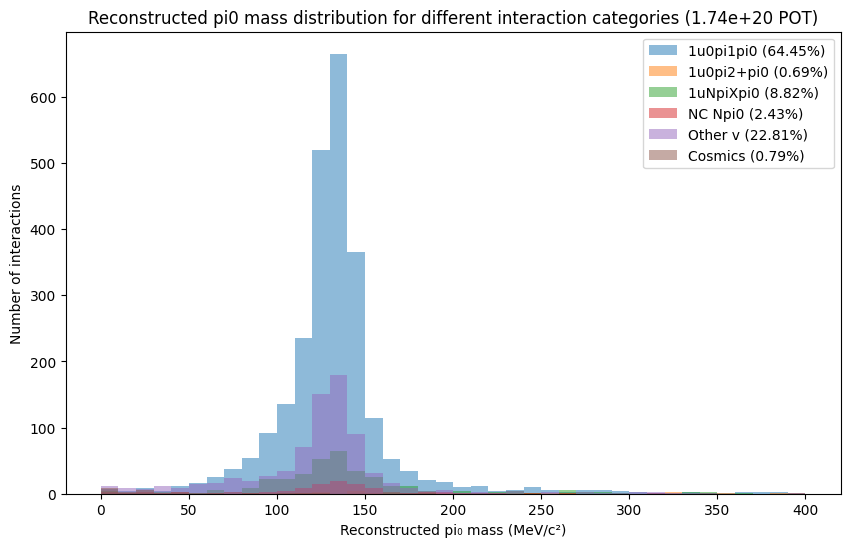

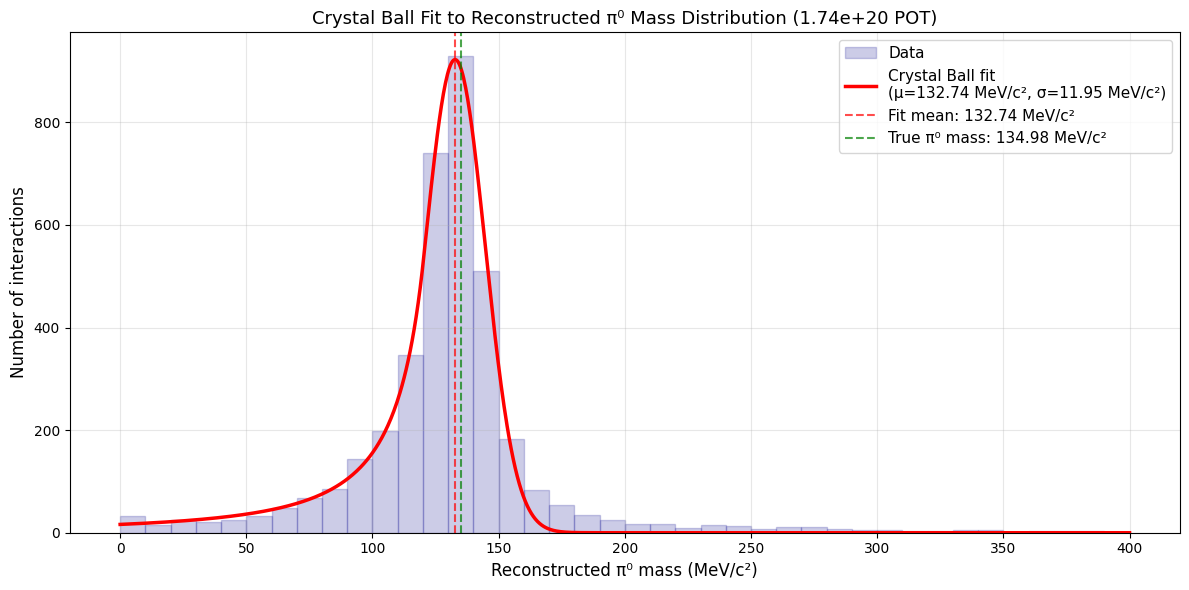

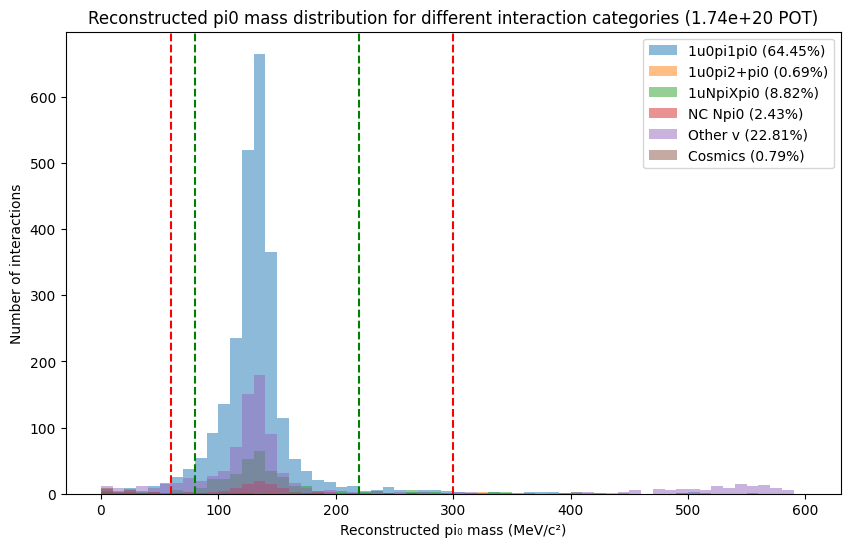

In [13]:
#BNB, input000.flat.root
#yy-shower truth selection 

#Importing relevant libraries
import numpy as np
import uproot
import pandas
import hist
import matplotlib.pyplot as plt

#enable this to see all outputs in a cell
#from IPython.core.interactiveshell import InteractiveShell
#InteractiveShell.ast_node_interactivity = "all"

#Opening the relevant ROOT file and tree
file = uproot.open(
    "e:/FYP/medulla_outputs/2_Shower_Selection_flashcut/NuMI_ccpi0ana_icarus_Jkoh1_initial_selection.root:events/NuMI_simulation/selected_nu_initialselection"
)

#showing all TBranches
file.keys()

#Reconstructed neutral pion mass plotting ===============================================================================================================

#Combining interaction category variable and pi0 mass variable for easier analysis
combinedcategory = file.arrays(["true_category_topology_ccpi0_simple2","reco_pi0_mass"],library="pd")

#Removing interactions with pi0 mass greater than 400 MeV/c^2 as they are not relevant for our analysis and are likely background interactions
POT = 1.74e20

#Splitting the interaction category variable into the relevant categories

#cosmics category: interactions that are not neutrino interactions (true_category_topology_ccpi0_simple2 is NaN)
cosmics_category = combinedcategory[combinedcategory["true_category_topology_ccpi0_simple2"].isna()]
print(f"Number of cosmic interactions and percentage: {len(cosmics_category)} out of {len(combinedcategory)} ({len(cosmics_category)/len(combinedcategory)*100:.2f}%)")

#neutrino 1mu1pi0 category: Neutrino interactions with 1 primary muon, 0 primary charged pions, and 1 primary neutral pion (true_category_topology_ccpi0_simple2 == 0)
neutrino_1mu0pi1pi0_category = combinedcategory[combinedcategory["true_category_topology_ccpi0_simple2"] == 0]
print(f"Number of 1mu0pi1pi0 CC neutrinointeractions and percentage: {len(neutrino_1mu0pi1pi0_category)} out of {len(combinedcategory)} ({len(neutrino_1mu0pi1pi0_category)/len(combinedcategory)*100:.2f}%)")

#neutrino 1mu0pi2pluspi0 category: Neutrino interactions with 1 primary muon, 0 primary charged pions, and 2 or more primary neutral pions (true_category_topology_ccpi0_simple2 == 1)
neutrino_1mu0pi2pluspi0_category = combinedcategory[combinedcategory["true_category_topology_ccpi0_simple2"] == 1]
print(f"Number of 1mu0pi2+pi0 CC neutrino interactions and percentage: {len(neutrino_1mu0pi2pluspi0_category)} out of {len(combinedcategory)} ({len(neutrino_1mu0pi2pluspi0_category)/len(combinedcategory)*100:.2f}%)")

#neutrino 1muNpiXpi0 category: Neutrino interactions with 1 primary muon, N primary charged pions (N>=1), and any number of primary neutral pions (true_category_topology_ccpi0_simple2 == 2)
neutrino_1muNpiXpi0_category = combinedcategory[combinedcategory["true_category_topology_ccpi0_simple2"] == 2]
print(f"Number of 1muNpiXpi0 CC neutrino interactions and percentage: {len(neutrino_1muNpiXpi0_category)} out of {len(combinedcategory)} ({len(neutrino_1muNpiXpi0_category)/len(combinedcategory)*100:.2f}%)")

#neutrino 0muNpi0 category: Neutrino interactions with 0 primary muons, N primary charged pions (N>=0), and any number of primary neutral pions (true_category_topology_ccpi0_simple2 == 3)
neutrino_0muNpi0_category = combinedcategory[combinedcategory["true_category_topology_ccpi0_simple2"] == 3]
print(f"Number of 0muNpi0 NC neutrino interactions and percentage: {len(neutrino_0muNpi0_category)} out of {len(combinedcategory)} ({len(neutrino_0muNpi0_category)/len(combinedcategory)*100:.2f}%)")

#neutrino othernu category: Neutrino interactions that do not fall into the above categories (true_category_topology_ccpi0_simple2 == 4)
neutrino_othernu_category = combinedcategory[combinedcategory["true_category_topology_ccpi0_simple2"] == 4]
print(f"Number of other neutrino interactions and percentage: {len(neutrino_othernu_category)} out of {len(combinedcategory)} ({len(neutrino_othernu_category)/len(combinedcategory)*100:.2f}%)")

#Plotting the pi0 mass distribution for each category into one histogram
plt.figure(figsize=(10,6))
plt.hist(neutrino_1mu0pi1pi0_category["reco_pi0_mass"], bins=40, range=(0, 400), alpha=0.5, label=f"1u0pi1pi0 ({len(neutrino_1mu0pi1pi0_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(neutrino_1mu0pi2pluspi0_category["reco_pi0_mass"], bins=40, range=(0, 400), alpha=0.5, label=f"1u0pi2+pi0 ({len(neutrino_1mu0pi2pluspi0_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(neutrino_1muNpiXpi0_category["reco_pi0_mass"], bins=40, range=(0, 400), alpha=0.5, label=f"1uNpiXpi0 ({len(neutrino_1muNpiXpi0_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(neutrino_0muNpi0_category["reco_pi0_mass"], bins=40, range=(0, 400), alpha=0.5, label=f"NC Npi0 ({len(neutrino_0muNpi0_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(neutrino_othernu_category["reco_pi0_mass"], bins=40, range=(0, 400), alpha=0.5, label=f"Other v ({len(neutrino_othernu_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(cosmics_category["reco_pi0_mass"], bins=40, range=(0, 400), alpha=0.5, label=f"Cosmics ({len(cosmics_category)/len(combinedcategory)*100:.2f}%)")
plt.legend()
plt.xlabel("Reconstructed pi₀ mass (MeV/c²)")
plt.ylabel("Number of interactions")
plt.title(f"Reconstructed pi0 mass distribution for different interaction categories ({POT} POT)")

#Crystal Ball fitting  ===============================================================================================================

#Crystal Ball fit to reconstructed pi0 mass
from scipy.optimize import curve_fit

# Crystal Ball function definition
def crystalball(x, amplitude, mu, sigma, alpha, n):
    x = np.array(x)
    t = (x - mu) / sigma
    abs_alpha = np.abs(alpha)
    A = (n / abs_alpha) ** n * np.exp(-0.5 * abs_alpha ** 2)
    B = n / abs_alpha - abs_alpha
    f = np.where(t > -abs_alpha, np.exp(-0.5 * t ** 2), A * (B - t) ** (-n))
    return amplitude * f

# Extract mass values from the selected nu initial selection sample
mass_values = combinedcategory["reco_pi0_mass"].dropna().values

# Histogram the reconstructed mass
bins = 40
counts, edges = np.histogram(mass_values, bins=bins, range=(0, 400))
bin_centers = 0.5 * (edges[:-1] + edges[1:])

# Initial guesses for the fit: amplitude, mu, sigma, alpha, n
p0 = [counts.max(), 135.0, 20.0, 2.0, 3.0]

# Fit the Crystal Ball to the histogram counts
try:
    popt, pcov = curve_fit(crystalball, bin_centers, counts, p0=p0, maxfev=20000)
    print("Crystal Ball fit successful!")
except Exception as e:
    print(f"Fit failed: {e}")
    popt = None

# True neutral pion mass (PDG) in MeV/c^2
true_pi0_mass = 134.9768

# Plot the fit result
plt.figure(figsize=(12, 6))
plt.hist(mass_values, bins=bins, range=(0, 400), alpha=0.2, label="Data", color="darkblue", edgecolor="darkblue")

if popt is not None:
    amplitude, mu, sigma, alpha, n = popt
    x_fit = np.linspace(0, 400, 1000)
    y_fit = crystalball(x_fit, *popt)
    plt.plot(x_fit, y_fit, color="red", lw=2.5, label=f"Crystal Ball fit\n(μ={mu:.2f} MeV/c², σ={sigma:.2f} MeV/c²)")
    plt.axvline(mu, color="red", ls="--", alpha=0.7, linewidth=1.5, label=f"Fit mean: {mu:.2f} MeV/c²")
    plt.axvline(true_pi0_mass, color="green", ls="--", alpha=0.7, linewidth=1.5, label=f"True π⁰ mass: {true_pi0_mass:.2f} MeV/c²")
    
    # Compute correction factor
    correction_factor = mu / true_pi0_mass
    
    # Print results
    print(f"\n===== Crystal Ball Fit Results =====")
    print(f"Fitted mean (μ): {mu:.4f} MeV/c²")
    print(f"Fitted sigma (σ): {sigma:.4f} MeV/c²")
    print(f"Fitted alpha (α): {alpha:.4f}")
    print(f"Fitted power n: {n:.4f}")
    print(f"Fitted amplitude: {amplitude:.1f}")
    print(f"\nTrue π⁰ mass (PDG): {true_pi0_mass:.4f} MeV/c²")
    print(f"Multiplicative correction factor (μ / true π⁰ mass): {correction_factor:.6f}")
    print(f"====================================\n")
else:
    print("Crystal Ball fit did not converge; no correction factor computed.")

plt.xlabel("Reconstructed π⁰ mass (MeV/c²)", fontsize=12)
plt.ylabel("Number of interactions", fontsize=12)
plt.title(f"Crystal Ball Fit to Reconstructed π⁰ Mass Distribution ({POT:.2e} POT)", fontsize=13)
plt.legend(fontsize=11, loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#Reconstructed invariant Diphoton mass cut selection ===============================================================================================================

#Extending reconstructed neutral pion mass plot to 600 MeV/c^2
plt.figure(figsize=(10,6))
plt.hist(neutrino_1mu0pi1pi0_category["reco_pi0_mass"], bins=60, range=(0, 600), alpha=0.5, label=f"1u0pi1pi0 ({len(neutrino_1mu0pi1pi0_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(neutrino_1mu0pi2pluspi0_category["reco_pi0_mass"], bins=60, range=(0, 600), alpha=0.5, label=f"1u0pi2+pi0 ({len(neutrino_1mu0pi2pluspi0_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(neutrino_1muNpiXpi0_category["reco_pi0_mass"], bins=60, range=(0, 600), alpha=0.5, label=f"1uNpiXpi0 ({len(neutrino_1muNpiXpi0_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(neutrino_0muNpi0_category["reco_pi0_mass"], bins=60, range=(0, 600), alpha=0.5, label=f"NC Npi0 ({len(neutrino_0muNpi0_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(neutrino_othernu_category["reco_pi0_mass"], bins=60, range=(0, 600), alpha=0.5, label=f"Other v ({len(neutrino_othernu_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(cosmics_category["reco_pi0_mass"], bins=60, range=(0, 600), alpha=0.5, label=f"Cosmics ({len(cosmics_category)/len(combinedcategory)*100:.2f}%)")
plt.legend()
plt.xlabel("Reconstructed pi₀ mass (MeV/c²)")
plt.ylabel("Number of interactions")
plt.title(f"Reconstructed pi0 mass distribution for different interaction categories ({POT} POT)")

#Create a red vertical line at 60 and 300 MeV on the plot 
plt.axvline(x=60, color='red', linestyle='--', label='Pi0 mass cut MeV/c^2 = 60')
plt.axvline(x=300, color='red', linestyle='--', label='Pi0 mass cut MeV/c^2 = 300')

#create a green vertical line at 80 MeV and 220 Mev on the plot
plt.axvline(x=80, color='green', linestyle='--', label='Pi0 mass cut MeV/c^2 = 80')
plt.axvline(x=220, color='green', linestyle='--', label='Pi0 mass cut MeV/c^2 = 220')













<h2 style="font-size: 24px;">1.4. Initial selection POT analysis</h2>

In [25]:
#BNB, input000.flat.root
#yy-shower truth selection 

#Importing relevant libraries
import numpy as np
import uproot
import pandas
import hist
import matplotlib.pyplot as plt

#enable this to see all outputs in a cell
#from IPython.core.interactiveshell import InteractiveShell
#InteractiveShell.ast_node_interactivity = "all"

#Opening the relevant ROOT file and tree
file = uproot.open(
    "e:/FYP/medulla_outputs/2_Shower_Selection_flashcut/NuMI_ccpi0ana_icarus_Jkoh1_initial_selection.root:events/NuMI_simulation/selected_nu_initialselection_exposure"
)

#showing all TBranches
file.keys()

POT = file.arrays(["pot"],library="pd")
POT

#Add the POT value of each index all together to get the total POT of the file
total_POT = POT["pot"].sum()
total_POT

np.float64(1.4711493479240407e+20)

<h2 style="font-size: 24px;">1.5. Particle PID confusion matrix</h2>

<h2 style="font-size: 24px;">1.5.1 Reco to Truth confusion matrix</h2>

Percentage of correctly identified photons:  86.72355261950638 %
Percentage of reco photons that are actually NULL:  8.285163776493256 %
Percentage of reco photons that are actually ELECTRON:  4.110468850353243 %
Percentage of reco photons that are actually MUON:  0.5505092210294523 %
Percentage of reco photons that are actually PION:  0.10092669052206625 %
Percentage of reco photons that are actually PROTON:  0.2293788420956051 %
Percentage of correctly identified electrons:  84.83821983413152 %
Percentage of reco electrons that are actually NULL:  2.4062609508235018 %
Percentage of reco electrons that are actually PHOTON:  2.24272865319472 %
Percentage of reco electrons that are actually MUON:  9.975470155355683 %
Percentage of reco electrons that are actually PION:  0.2686602032472842 %
Percentage of reco electrons that are actually PROTON:  0.2686602032472842 %
Percentage of correctly identified muons:  85.57213930348259 %
Percentage of reco muons that are actually NULL:  0.2487562

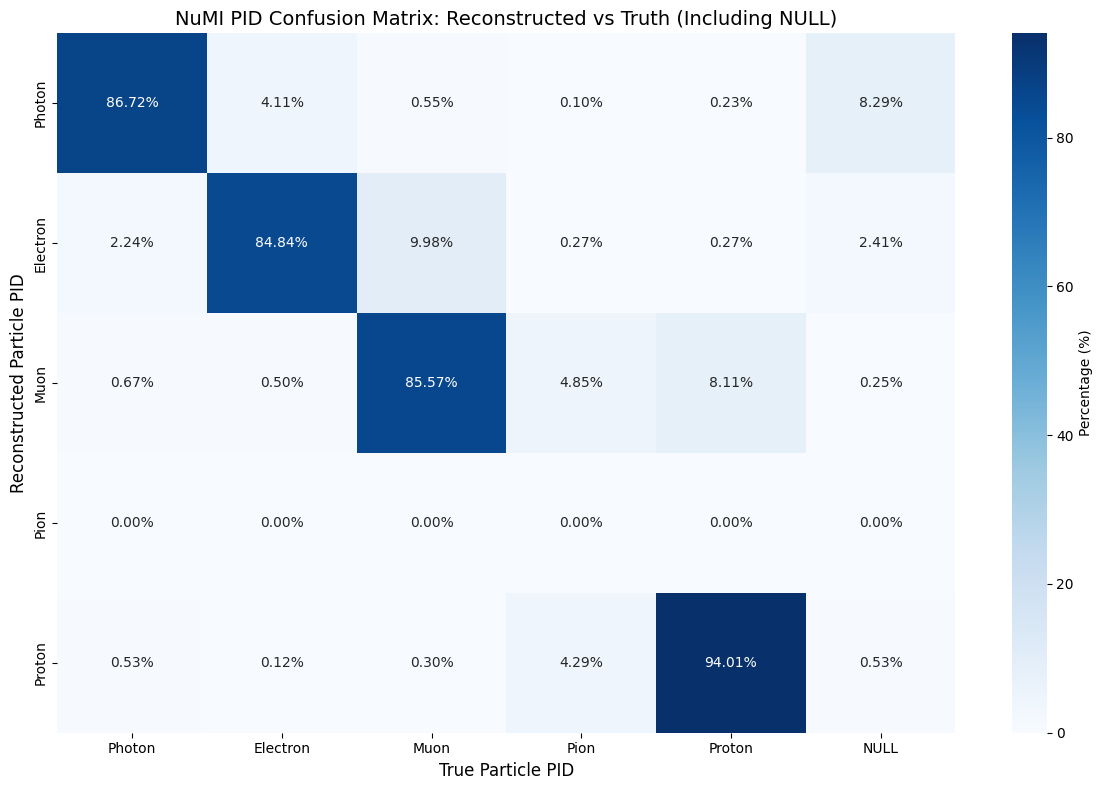

In [27]:
#BNB
#Preselection confusion matrix reco to truth selection 

#Importing relevant libraries
import numpy as np
import uproot
import pandas
import hist
import matplotlib.pyplot as plt
import seaborn as sns


#enable this to see all outputs in a cell
#from IPython.core.interactiveshell import InteractiveShell
#InteractiveShell.ast_node_interactivity = "all"

#Opening the relevant ROOT file and tree
file = uproot.open(
    "e:/FYP/medulla_outputs/2_Shower_Selection_flashcut/NuMI_ccpi0ana_icarus_Jkoh1_initial_selection.root:events/NuMI_simulation/PID_selected_nu"
)
#showing all TBranches
file.keys()

#Extracting reco and true Photon PID from TBranches
combinedPID = file.arrays(["reco_particle_pid", "true_particle_pid","reco_particle_ke"],library="pd")

#removing low energy charged pions 
combinedPID = combinedPID[(combinedPID["reco_particle_pid"] != 3) ]




correctrecoPhoton = combinedPID[(combinedPID["reco_particle_pid"] == 0) & (combinedPID["true_particle_pid"] == 0)]
correctrecoPhoton
totalrecoPhoton = combinedPID[combinedPID["reco_particle_pid"] == 0]
totalrecoPhoton
percentagecorrectPhoton = (len(correctrecoPhoton)/len(totalrecoPhoton))*100
percentagecorrectPhoton
wrongrecoPhotonNULL = combinedPID[(combinedPID["reco_particle_pid"] == 0) & (combinedPID["true_particle_pid"].isna())]
percenragewrongrecoPhotonNULL = (len(wrongrecoPhotonNULL)/len(totalrecoPhoton))*100
wrongrecoPhotoELECTRON = combinedPID[(combinedPID["reco_particle_pid"] == 0) & (combinedPID["true_particle_pid"] == 1)] 
percentagewrongrecoPhotoELECTRON = (len(wrongrecoPhotoELECTRON)/len(totalrecoPhoton))*100
wrongrecoPhotoMUON = combinedPID[(combinedPID["reco_particle_pid"] == 0) & (combinedPID["true_particle_pid"] == 2)]
percentagewrongrecoPhotoMUON = (len(wrongrecoPhotoMUON)/len(totalrecoPhoton))*100
wrongrecoPhotoPION = combinedPID[(combinedPID["reco_particle_pid"] == 0) & (combinedPID["true_particle_pid"] == 3)]
percentagewrongrecoPhotoPION = (len(wrongrecoPhotoPION)/len(totalrecoPhoton))*100
wrongrecoPhotoPROTON = combinedPID[(combinedPID["reco_particle_pid"] == 0) & (combinedPID["true_particle_pid"] == 4)]
percentagewrongrecoPhotoPROTON = (len(wrongrecoPhotoPROTON)/len(totalrecoPhoton))*100

print("Percentage of correctly identified photons: ", percentagecorrectPhoton, "%")
print("Percentage of reco photons that are actually NULL: ", percenragewrongrecoPhotonNULL, "%")
print("Percentage of reco photons that are actually ELECTRON: ", percentagewrongrecoPhotoELECTRON, "%")
print("Percentage of reco photons that are actually MUON: ", percentagewrongrecoPhotoMUON, "%")
print("Percentage of reco photons that are actually PION: ", percentagewrongrecoPhotoPION, "%")
print("Percentage of reco photons that are actually PROTON: ", percentagewrongrecoPhotoPROTON, "%")

#Extracting reco and true Electron PID from TBranches

correctrecoElectron = combinedPID[(combinedPID["reco_particle_pid"] == 1) & (combinedPID["true_particle_pid"] == 1)]
correctrecoElectron
totalrecoElectron = combinedPID[combinedPID["reco_particle_pid"] == 1]
totalrecoElectron
percentagecorrectElectron = (len(correctrecoElectron)/len(totalrecoElectron))*100
percentagecorrectElectron
wrongrecoElectronNULL = combinedPID[(combinedPID["reco_particle_pid"] == 1) & (combinedPID["true_particle_pid"].isna())]
percenragewrongrecoElectronNULL = (len(wrongrecoElectronNULL)/len(totalrecoElectron))*100
wrongrecoElectronPHOTON = combinedPID[(combinedPID["reco_particle_pid"] == 1) & (combinedPID["true_particle_pid"] == 0)] 
percentagewrongrecoElectronPHOTON = (len(wrongrecoElectronPHOTON)/len(totalrecoElectron))*100
wrongrecoElectronMUON = combinedPID[(combinedPID["reco_particle_pid"] == 1) & (combinedPID["true_particle_pid"] == 2)]
percentagewrongrecoElectronMUON = (len(wrongrecoElectronMUON)/len(totalrecoElectron))*100
wrongrecoElectronPION = combinedPID[(combinedPID["reco_particle_pid"] == 1) & (combinedPID["true_particle_pid"] == 3)]
percentagewrongrecoElectronPION = (len(wrongrecoElectronPION)/len(totalrecoElectron))*100
wrongrecoElectronPROTON = combinedPID[(combinedPID["reco_particle_pid"] == 1) & (combinedPID["true_particle_pid"] == 4)]
percentagewrongrecoElectronPROTON = (len(wrongrecoElectronPROTON)/len(totalrecoElectron))*100

print("Percentage of correctly identified electrons: ", percentagecorrectElectron, "%")
print("Percentage of reco electrons that are actually NULL: ", percenragewrongrecoElectronNULL, "%")
print("Percentage of reco electrons that are actually PHOTON: ", percentagewrongrecoElectronPHOTON, "%")
print("Percentage of reco electrons that are actually MUON: ", percentagewrongrecoElectronMUON, "%")
print("Percentage of reco electrons that are actually PION: ", percentagewrongrecoElectronPION, "%")
print("Percentage of reco electrons that are actually PROTON: ", percentagewrongrecoElectronPROTON, "%")

#Extracting reco and true Muon PID from TBranches

correctrecoMuon = combinedPID[(combinedPID["reco_particle_pid"] == 2) & (combinedPID["true_particle_pid"] == 2)]
correctrecoMuon
totalrecoMuon = combinedPID[combinedPID["reco_particle_pid"] == 2]
totalrecoMuon
percentagecorrectMuon = (len(correctrecoMuon)/len(totalrecoMuon))*100
percentagecorrectMuon
wrongrecoMuonNULL = combinedPID[(combinedPID["reco_particle_pid"] == 2) & (combinedPID["true_particle_pid"].isna())]
percenragewrongrecoMuonNULL = (len(wrongrecoMuonNULL)/len(totalrecoMuon))*100
wrongrecoMuonPHOTON = combinedPID[(combinedPID["reco_particle_pid"] == 2) & (combinedPID["true_particle_pid"] == 0)] 
percentagewrongrecoMuonPHOTON = (len(wrongrecoMuonPHOTON)/len(totalrecoMuon))*100
wrongrecoMuonMUON = combinedPID[(combinedPID["reco_particle_pid"] == 2) & (combinedPID["true_particle_pid"] == 1)]
percentagewrongrecoMuonMUON = (len(wrongrecoMuonMUON)/len(totalrecoMuon))*100
wrongrecoMuonPION = combinedPID[(combinedPID["reco_particle_pid"] == 2) & (combinedPID["true_particle_pid"] == 3)]
percentagewrongrecoMuonPION = (len(wrongrecoMuonPION)/len(totalrecoMuon))*100
wrongrecoMuonPROTON = combinedPID[(combinedPID["reco_particle_pid"] == 2) & (combinedPID["true_particle_pid"] == 4)]
percentagewrongrecoMuonPROTON = (len(wrongrecoMuonPROTON)/len(totalrecoMuon))*100

print("Percentage of correctly identified muons: ", percentagecorrectMuon, "%")
print("Percentage of reco muons that are actually NULL: ", percenragewrongrecoMuonNULL, "%")
print("Percentage of reco muons that are actually PHOTON: ", percentagewrongrecoMuonPHOTON, "%")
print("Percentage of reco muons that are actually MUON: ", percentagewrongrecoMuonMUON, "%")
print("Percentage of reco muons that are actually PION: ", percentagewrongrecoMuonPION, "%")
print("Percentage of reco muons that are actually PROTON: ", percentagewrongrecoMuonPROTON, "%")

#Extracting reco and true Pion PID from TBranches

correctrecoPion = combinedPID[(combinedPID["reco_particle_pid"] == 3) & (combinedPID["true_particle_pid"] == 3)]
correctrecoPion
totalrecoPion = combinedPID[combinedPID["reco_particle_pid"] == 3]
totalrecoPion
percentagecorrectPion = 0
percentagecorrectPion   
wrongrecoPionNULL = combinedPID[(combinedPID["reco_particle_pid"] == 3) & (combinedPID["true_particle_pid"].isna())]
percenragewrongrecoPionNULL = 0
wrongrecoPionPHOTON = combinedPID[(combinedPID["reco_particle_pid"] == 3) & (combinedPID["true_particle_pid"] == 0)] 
percentagewrongrecoPionPHOTON = 0
wrongrecoPionELECTRON = combinedPID[(combinedPID["reco_particle_pid"] == 3) & (combinedPID["true_particle_pid"] == 1)]
percentagewrongrecoPionELECTRON = 0
wrongrecoPionMUON = combinedPID[(combinedPID["reco_particle_pid"] == 3) & (combinedPID["true_particle_pid"] == 2)]
percentagewrongrecoPionMUON = 0
wrongrecoPionPROTON = combinedPID[(combinedPID["reco_particle_pid"] == 3) & (combinedPID["true_particle_pid"] == 4)]
percentagewrongrecoPionPROTON = 0

print("Percentage of correctly identified pions: ", percentagecorrectPion, "%")
print("Percentage of reco pions that are actually NULL: ", percenragewrongrecoPionNULL, "%")
print("Percentage of reco pions that are actually PHOTON: ", percentagewrongrecoPionPHOTON, "%")
print("Percentage of reco pions that are actually ELECTRON: ", percentagewrongrecoPionELECTRON, "%")
print("Percentage of reco pions that are actually MUON: ", percentagewrongrecoPionMUON, "%")
print("Percentage of reco pions that are actually PROTON: ", percentagewrongrecoPionPROTON, "%")

#Extracting reco and true Proton PID from TBranches

correctrecoProton = combinedPID[(combinedPID["reco_particle_pid"] == 4) & (combinedPID["true_particle_pid"] == 4)]
correctrecoProton
totalrecoProton = combinedPID[combinedPID["reco_particle_pid"] == 4]
totalrecoProton
percentagecorrectProton = (len(correctrecoProton)/len(totalrecoProton))*100
percentagecorrectProton   
wrongrecoProtonNULL = combinedPID[(combinedPID["reco_particle_pid"] == 4) & (combinedPID["true_particle_pid"].isna())]
percenragewrongrecoProtonNULL = (len(wrongrecoProtonNULL)/len(totalrecoProton))*100
wrongrecoProtonPHOTON = combinedPID[(combinedPID["reco_particle_pid"] == 4) & (combinedPID["true_particle_pid"] == 0)] 
percentagewrongrecoProtonPHOTON = (len(wrongrecoProtonPHOTON)/len(totalrecoProton))*100
wrongrecoProtonELECTRON = combinedPID[(combinedPID["reco_particle_pid"] == 4) & (combinedPID["true_particle_pid"] == 1)]
percentagewrongrecoProtonELECTRON = (len(wrongrecoProtonELECTRON)/len(totalrecoProton))*100
wrongrecoProtonMUON = combinedPID[(combinedPID["reco_particle_pid"] == 4) & (combinedPID["true_particle_pid"] == 2)]
percentagewrongrecoProtonMUON = (len(wrongrecoProtonMUON)/len(totalrecoProton))*100
wrongrecoProtonPION = combinedPID[(combinedPID["reco_particle_pid"] == 4) & (combinedPID["true_particle_pid"] == 3)]
percentagewrongrecoProtonPION = (len(wrongrecoProtonPION)/len(totalrecoProton))*100

print("Percentage of correctly identified protons: ", percentagecorrectProton, "%")
print("Percentage of reco protons that are actually NULL: ", percenragewrongrecoProtonNULL, "%")
print("Percentage of reco protons that are actually PHOTON: ", percentagewrongrecoProtonPHOTON, "%")
print("Percentage of reco protons that are actually ELECTRON: ", percentagewrongrecoProtonELECTRON, "%")
print("Percentage of reco protons that are actually MUON: ", percentagewrongrecoProtonMUON, "%")
print("Percentage of reco protons that are actually PION: ", percentagewrongrecoProtonPION, "%")

# Data from your analysis
particle_names = ['Photon', 'Electron', 'Muon', 'Pion', 'Proton',]

# Create confusion matrix (rows = reco, columns = true)
# Including NULL column
confusion_matrix = np.array([
    [percentagecorrectPhoton, percentagewrongrecoPhotoELECTRON, percentagewrongrecoPhotoMUON, percentagewrongrecoPhotoPION, percentagewrongrecoPhotoPROTON, percenragewrongrecoPhotonNULL],
    [percentagewrongrecoElectronPHOTON, percentagecorrectElectron, percentagewrongrecoElectronMUON, percentagewrongrecoElectronPION, percentagewrongrecoElectronPROTON, percenragewrongrecoElectronNULL],
    [percentagewrongrecoMuonPHOTON, percentagewrongrecoMuonMUON, percentagecorrectMuon, percentagewrongrecoMuonPION, percentagewrongrecoMuonPROTON, percenragewrongrecoMuonNULL],
    [percentagewrongrecoPionPHOTON, percentagewrongrecoPionELECTRON, percentagewrongrecoPionMUON, percentagecorrectPion, percentagewrongrecoPionPROTON, percenragewrongrecoPionNULL],
    [percentagewrongrecoProtonPHOTON, percentagewrongrecoProtonELECTRON, percentagewrongrecoProtonMUON, percentagewrongrecoProtonPION, percentagecorrectProton, percenragewrongrecoProtonNULL]
])

# Add NULL to particle names
particle_names_with_null = particle_names + ['NULL']

# Create heatmap with custom formatting
plt.figure(figsize=(12, 8))
sns.heatmap(confusion_matrix, annot=True, fmt='.2f', cmap='Blues', 
            xticklabels=particle_names_with_null, yticklabels=particle_names,
            cbar_kws={'label': 'Percentage (%)'},
            annot_kws={'fontsize': 10})

# Add % signs manually to annotations
ax = plt.gca()
for t in ax.texts:
    t.set_text(t.get_text() + "%")

plt.xlabel('True Particle PID', fontsize=12)
plt.ylabel('Reconstructed Particle PID', fontsize=12)
plt.title('NuMI PID Confusion Matrix: Reconstructed vs Truth (Including NULL)', fontsize=14)
plt.tight_layout()
plt.show()

# example using a stored energy branch


<h2 style="font-size: 24px;">1.5.2 Truth to Reco confusion matrix</h2>

Percentage of correctly identified photons:  81.07936507936509 %
Percentage of reco photons that are actually NULL:  8.261904761904763 %
Percentage of reco photons that are actually ELECTRON:  9.515873015873016 %
Percentage of reco photons that are actually MUON:  0.1746031746031746 %
Percentage of reco photons that are actually PION:  0.41269841269841273 %
Percentage of reco photons that are actually PROTON:  0.5555555555555556 %
Percentage of correctly identified electrons:  85.53688041965528 %
Percentage of reco electrons that are actually NULL:  0.4496306605288513 %
Percentage of reco electrons that are actually PHOTON:  4.143025372015844 %
Percentage of reco electrons that are actually MUON:  9.131784605502622 %
Percentage of reco electrons that are actually PION:  0.43892516861149766 %
Percentage of reco electrons that are actually PROTON:  0.29975377368590084 %
Percentage of correctly identified muons:  95.06204756980352 %
Percentage of reco muons that are actually NULL:  0.0 %


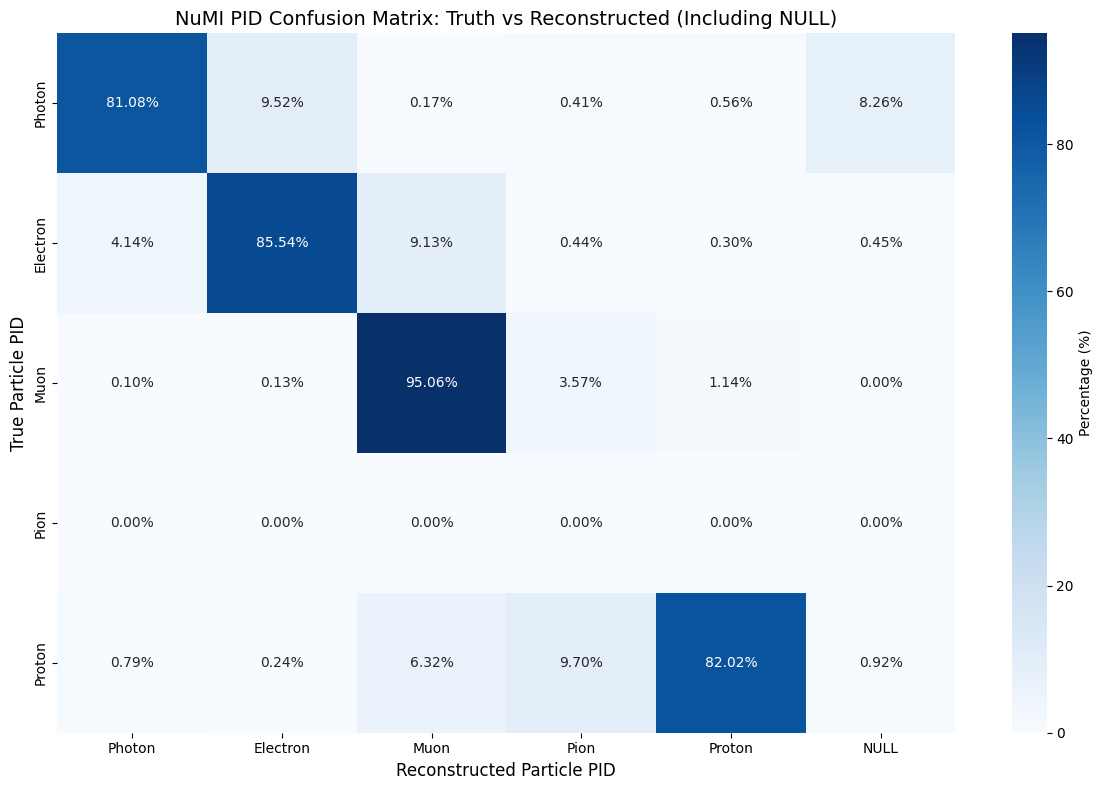

In [29]:
#BNB 
#Preselection confusion matrix truth to reco selection 

#Importing relevant libraries
import numpy as np
import uproot
import pandas
import hist
import matplotlib.pyplot as plt
import seaborn as sns


#enable this to see all outputs in a cell
#from IPython.core.interactiveshell import InteractiveShell
#InteractiveShell.ast_node_interactivity = "all"

#Opening the relevant ROOT file and tree
file = uproot.open(
    "e:/FYP/medulla_outputs/2_Shower_Selection_flashcut/NuMI_ccpi0ana_icarus_Jkoh1_PID_MATRIX_signal.root:events/NuMI_simulation/signal"
)

#showing all TBranches
file.keys()

#Extracting reco and true Photon PID from TBranches

combinedPID = file.arrays(["reco_particle_pid", "true_particle_pid"],library="pd")
combinedPID

#Removing charged pions 
combinedPID = combinedPID[(combinedPID["true_particle_pid"] != 3) ]

correctrecoPhoton = combinedPID[(combinedPID["reco_particle_pid"] == 0) & (combinedPID["true_particle_pid"] == 0)]
correctrecoPhoton
totaltruePhoton = combinedPID[combinedPID["true_particle_pid"] == 0]
totaltruePhoton
percentagecorrectPhoton = (len(correctrecoPhoton)/len(totaltruePhoton))*100
percentagecorrectPhoton
wrongrecoPhotonNULL = combinedPID[(combinedPID["true_particle_pid"] == 0) & (combinedPID["reco_particle_pid"].isna())]
percenragewrongrecoPhotonNULL = (len(wrongrecoPhotonNULL)/len(totaltruePhoton))*100
wrongrecoPhotoELECTRON = combinedPID[(combinedPID["true_particle_pid"] == 0) & (combinedPID["reco_particle_pid"] == 1)] 
percentagewrongrecoPhotoELECTRON = (len(wrongrecoPhotoELECTRON)/len(totaltruePhoton))*100
wrongrecoPhotoMUON = combinedPID[(combinedPID["true_particle_pid"] == 0) & (combinedPID["reco_particle_pid"] == 2)]
percentagewrongrecoPhotoMUON = (len(wrongrecoPhotoMUON)/len(totaltruePhoton))*100
wrongrecoPhotoPION = combinedPID[(combinedPID["true_particle_pid"] == 0) & (combinedPID["reco_particle_pid"] == 3)]
percentagewrongrecoPhotoPION = (len(wrongrecoPhotoPION)/len(totaltruePhoton))*100
wrongrecoPhotoPROTON = combinedPID[(combinedPID["true_particle_pid"] == 0) & (combinedPID["reco_particle_pid"] == 4)]
percentagewrongrecoPhotoPROTON = (len(wrongrecoPhotoPROTON)/len(totaltruePhoton))*100

print("Percentage of correctly identified photons: ", percentagecorrectPhoton, "%")
print("Percentage of reco photons that are actually NULL: ", percenragewrongrecoPhotonNULL, "%")
print("Percentage of reco photons that are actually ELECTRON: ", percentagewrongrecoPhotoELECTRON, "%")
print("Percentage of reco photons that are actually MUON: ", percentagewrongrecoPhotoMUON, "%")
print("Percentage of reco photons that are actually PION: ", percentagewrongrecoPhotoPION, "%")
print("Percentage of reco photons that are actually PROTON: ", percentagewrongrecoPhotoPROTON, "%")

#Extracting reco and true Electron PID from TBranches

correctrecoElectron = combinedPID[(combinedPID["reco_particle_pid"] == 1) & (combinedPID["true_particle_pid"] == 1)]
correctrecoElectron
totaltrueElectron = combinedPID[combinedPID["true_particle_pid"] == 1]
totaltrueElectron
percentagecorrectElectron = (len(correctrecoElectron)/len(totaltrueElectron))*100
percentagecorrectElectron
wrongrecoElectronNULL = combinedPID[(combinedPID["true_particle_pid"] == 1) & (combinedPID["reco_particle_pid"].isna())]
percenragewrongrecoElectronNULL = (len(wrongrecoElectronNULL)/len(totaltrueElectron))*100
wrongrecoElectronPHOTON = combinedPID[(combinedPID["true_particle_pid"] == 1) & (combinedPID["reco_particle_pid"] == 0)] 
percentagewrongrecoElectronPHOTON = (len(wrongrecoElectronPHOTON)/len(totaltrueElectron))*100
wrongrecoElectronMUON = combinedPID[(combinedPID["true_particle_pid"] == 1) & (combinedPID["reco_particle_pid"] == 2)]
percentagewrongrecoElectronMUON = (len(wrongrecoElectronMUON)/len(totaltrueElectron))*100
wrongrecoElectronPION = combinedPID[(combinedPID["true_particle_pid"] == 1) & (combinedPID["reco_particle_pid"] == 3)]
percentagewrongrecoElectronPION = (len(wrongrecoElectronPION)/len(totaltrueElectron))*100
wrongrecoElectronPROTON = combinedPID[(combinedPID["true_particle_pid"] == 1) & (combinedPID["reco_particle_pid"] == 4)]
percentagewrongrecoElectronPROTON = (len(wrongrecoElectronPROTON)/len(totaltrueElectron))*100

print("Percentage of correctly identified electrons: ", percentagecorrectElectron, "%")
print("Percentage of reco electrons that are actually NULL: ", percenragewrongrecoElectronNULL, "%")
print("Percentage of reco electrons that are actually PHOTON: ", percentagewrongrecoElectronPHOTON, "%")
print("Percentage of reco electrons that are actually MUON: ", percentagewrongrecoElectronMUON, "%")
print("Percentage of reco electrons that are actually PION: ", percentagewrongrecoElectronPION, "%")
print("Percentage of reco electrons that are actually PROTON: ", percentagewrongrecoElectronPROTON, "%")

#Extracting reco and true Muon PID from TBranches

correctrecoMuon = combinedPID[(combinedPID["reco_particle_pid"] == 2) & (combinedPID["true_particle_pid"] == 2)]
correctrecoMuon
totaltrueMuon = combinedPID[combinedPID["true_particle_pid"] == 2]
totaltrueMuon
percentagecorrectMuon = (len(correctrecoMuon)/len(totaltrueMuon))*100
percentagecorrectMuon
wrongrecoMuonNULL = combinedPID[(combinedPID["true_particle_pid"] == 2) & (combinedPID["reco_particle_pid"].isna())]
percenragewrongrecoMuonNULL = (len(wrongrecoMuonNULL)/len(totaltrueMuon))*100
wrongrecoMuonPHOTON = combinedPID[(combinedPID["true_particle_pid"] == 2) & (combinedPID["reco_particle_pid"] == 0)] 
percentagewrongrecoMuonPHOTON = (len(wrongrecoMuonPHOTON)/len(totaltrueMuon))*100
wrongrecoMuonMUON = combinedPID[(combinedPID["true_particle_pid"] == 2) & (combinedPID["reco_particle_pid"] == 1)]
percentagewrongrecoMuonMUON = (len(wrongrecoMuonMUON)/len(totaltrueMuon))*100
wrongrecoMuonPION = combinedPID[(combinedPID["true_particle_pid"] == 2) & (combinedPID["reco_particle_pid"] == 3)]
percentagewrongrecoMuonPION = (len(wrongrecoMuonPION)/len(totaltrueMuon))*100
wrongrecoMuonPROTON = combinedPID[(combinedPID["true_particle_pid"] == 2) & (combinedPID["reco_particle_pid"] == 4)]
percentagewrongrecoMuonPROTON = (len(wrongrecoMuonPROTON)/len(totaltrueMuon))*100

print("Percentage of correctly identified muons: ", percentagecorrectMuon, "%")
print("Percentage of reco muons that are actually NULL: ", percenragewrongrecoMuonNULL, "%")
print("Percentage of reco muons that are actually PHOTON: ", percentagewrongrecoMuonPHOTON, "%")
print("Percentage of reco muons that are actually MUON: ", percentagewrongrecoMuonMUON, "%")
print("Percentage of reco muons that are actually PION: ", percentagewrongrecoMuonPION, "%")
print("Percentage of reco muons that are actually PROTON: ", percentagewrongrecoMuonPROTON, "%")

#Extracting reco and true Pion PID from TBranches

correctrecoPion = combinedPID[(combinedPID["reco_particle_pid"] == 3) & (combinedPID["true_particle_pid"] == 3)]
correctrecoPion
totaltruePion = combinedPID[combinedPID["true_particle_pid"] == 3]
totaltruePion
percentagecorrectPion = 0
percentagecorrectPion  
wrongrecoPionNULL = combinedPID[(combinedPID["true_particle_pid"] == 3) & (combinedPID["reco_particle_pid"].isna())]
percenragewrongrecoPionNULL = 0
wrongrecoPionPHOTON = combinedPID[(combinedPID["true_particle_pid"] == 3) & (combinedPID["reco_particle_pid"] == 0)] 
percentagewrongrecoPionPHOTON = 0
wrongrecoPionELECTRON = combinedPID[(combinedPID["true_particle_pid"] == 3) & (combinedPID["reco_particle_pid"] == 1)]
percentagewrongrecoPionELECTRON = 0
wrongrecoPionMUON = combinedPID[(combinedPID["true_particle_pid"] == 3) & (combinedPID["reco_particle_pid"] == 2)]
percentagewrongrecoPionMUON = 0
wrongrecoPionPROTON = combinedPID[(combinedPID["true_particle_pid"] == 3) & (combinedPID["reco_particle_pid"] == 4)]
percentagewrongrecoPionPROTON = 0

print("Percentage of correctly identified pions: ", percentagecorrectPion, "%")
print("Percentage of reco pions that are actually NULL: ", percenragewrongrecoPionNULL, "%")
print("Percentage of reco pions that are actually PHOTON: ", percentagewrongrecoPionPHOTON, "%")
print("Percentage of reco pions that are actually ELECTRON: ", percentagewrongrecoPionELECTRON, "%")
print("Percentage of reco pions that are actually MUON: ", percentagewrongrecoPionMUON, "%")
print("Percentage of reco pions that are actually PROTON: ", percentagewrongrecoPionPROTON, "%")

#Extracting reco and true Proton PID from TBranches

correctrecoProton = combinedPID[(combinedPID["reco_particle_pid"] == 4) & (combinedPID["true_particle_pid"] == 4)]
correctrecoProton
totaltrueProton = combinedPID[combinedPID["true_particle_pid"] == 4]
totaltrueProton
percentagecorrectProton = (len(correctrecoProton)/len(totaltrueProton))*100
percentagecorrectProton   
wrongrecoProtonNULL = combinedPID[(combinedPID["true_particle_pid"] == 4) & (combinedPID["reco_particle_pid"].isna())]
percenragewrongrecoProtonNULL = (len(wrongrecoProtonNULL)/len(totaltrueProton))*100
wrongrecoProtonPHOTON = combinedPID[(combinedPID["true_particle_pid"] == 4) & (combinedPID["reco_particle_pid"] == 0)] 
percentagewrongrecoProtonPHOTON = (len(wrongrecoProtonPHOTON)/len(totaltrueProton))*100
wrongrecoProtonELECTRON = combinedPID[(combinedPID["true_particle_pid"] == 4) & (combinedPID["reco_particle_pid"] == 1)]
percentagewrongrecoProtonELECTRON = (len(wrongrecoProtonELECTRON)/len(totaltrueProton))*100
wrongrecoProtonMUON = combinedPID[(combinedPID["true_particle_pid"] == 4) & (combinedPID["reco_particle_pid"] == 2)]
percentagewrongrecoProtonMUON = (len(wrongrecoProtonMUON)/len(totaltrueProton))*100
wrongrecoProtonPION = combinedPID[(combinedPID["true_particle_pid"] == 4) & (combinedPID["reco_particle_pid"] == 3)]
percentagewrongrecoProtonPION = (len(wrongrecoProtonPION)/len(totaltrueProton))*100

print("Percentage of correctly identified protons: ", percentagecorrectProton, "%")
print("Percentage of reco protons that are actually NULL: ", percenragewrongrecoProtonNULL, "%")
print("Percentage of reco protons that are actually PHOTON: ", percentagewrongrecoProtonPHOTON, "%")
print("Percentage of reco protons that are actually ELECTRON: ", percentagewrongrecoProtonELECTRON, "%")
print("Percentage of reco protons that are actually MUON: ", percentagewrongrecoProtonMUON, "%")
print("Percentage of reco protons that are actually PION: ", percentagewrongrecoProtonPION, "%")


# Data from your analysis
yparticle_names = ['Photon', 'Electron', 'Muon', 'Pion','Proton']
xparticle_names = ['Photon', 'Electron', 'Muon', 'Pion', 'Proton','NULL']

# Create confusion matrix (rows = reco, columns = true)
# Including NULL column
confusion_matrix = np.array([
    [percentagecorrectPhoton, percentagewrongrecoPhotoELECTRON, percentagewrongrecoPhotoMUON, percentagewrongrecoPhotoPION, percentagewrongrecoPhotoPROTON, percenragewrongrecoPhotonNULL],
    [percentagewrongrecoElectronPHOTON, percentagecorrectElectron, percentagewrongrecoElectronMUON, percentagewrongrecoElectronPION, percentagewrongrecoElectronPROTON, percenragewrongrecoElectronNULL],
    [percentagewrongrecoMuonPHOTON, percentagewrongrecoMuonMUON, percentagecorrectMuon, percentagewrongrecoMuonPION, percentagewrongrecoMuonPROTON, percenragewrongrecoMuonNULL],
    [percentagewrongrecoPionPHOTON, percentagewrongrecoPionELECTRON, percentagewrongrecoPionMUON, percentagecorrectPion, percentagewrongrecoPionPROTON, percenragewrongrecoPionNULL],
    [percentagewrongrecoProtonPHOTON, percentagewrongrecoProtonELECTRON, percentagewrongrecoProtonMUON, percentagewrongrecoProtonPION, percentagecorrectProton, percenragewrongrecoProtonNULL]
])



# Create heatmap with custom formatting
plt.figure(figsize=(12, 8))
sns.heatmap(confusion_matrix, annot=True, fmt='.2f', cmap='Blues', 
            xticklabels=xparticle_names, yticklabels=yparticle_names,
            cbar_kws={'label': 'Percentage (%)'},
            annot_kws={'fontsize': 10})

# Add % signs manually to annotations
ax = plt.gca()
for t in ax.texts:
    t.set_text(t.get_text() + "%")

plt.xlabel('Reconstructed Particle PID', fontsize=12)
plt.ylabel('True Particle PID', fontsize=12)
plt.title('NuMI PID Confusion Matrix: Truth vs Reconstructed (Including NULL)', fontsize=14)
plt.tight_layout()
plt.show()

<h2 style="font-size: 24px;">1.6. Reconstructed Observables</h2>

<h2 style="font-size: 24px;">1.6.1 Low-Level Observables</h2>

Number of cosmic interactions and percentage: 9 out of 3566 (0.25%)
Number of 1mu0pi1pi0 CC neutrinointeractions and percentage: 2434 out of 3566 (68.26%)
Number of 1mu0pi2+pi0 CC neutrino interactions and percentage: 22 out of 3566 (0.62%)
Number of 1muNpiXpi0 CC neutrino interactions and percentage: 321 out of 3566 (9.00%)
Number of 0muNpi0 NC neutrino interactions and percentage: 86 out of 3566 (2.41%)
Number of other neutrino interactions and percentage: 694 out of 3566 (19.46%)


Text(0.5, 1.0, 'Reconstrcted subleading photon conversion distance for different interaction categories (174e20 POT)')

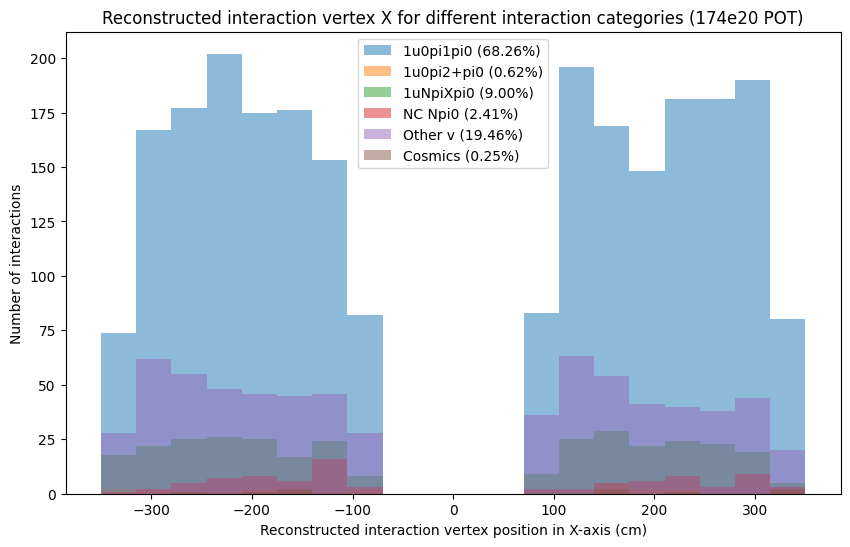

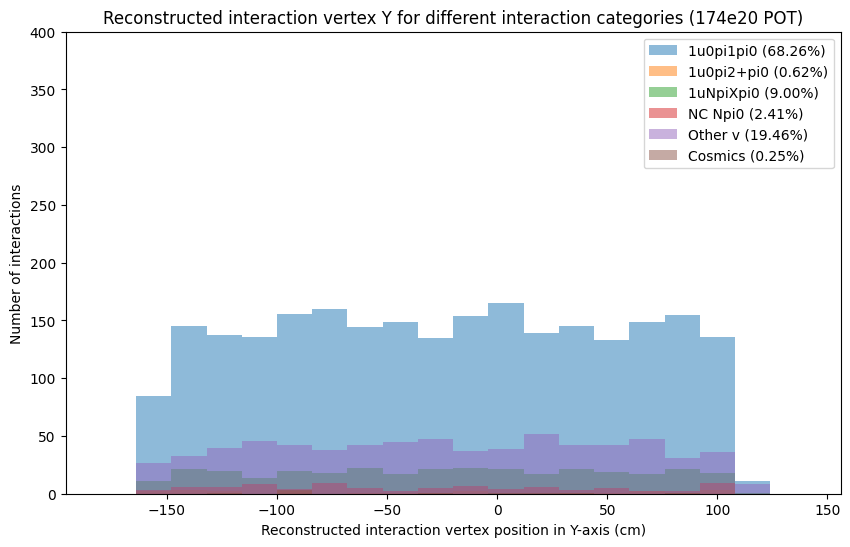

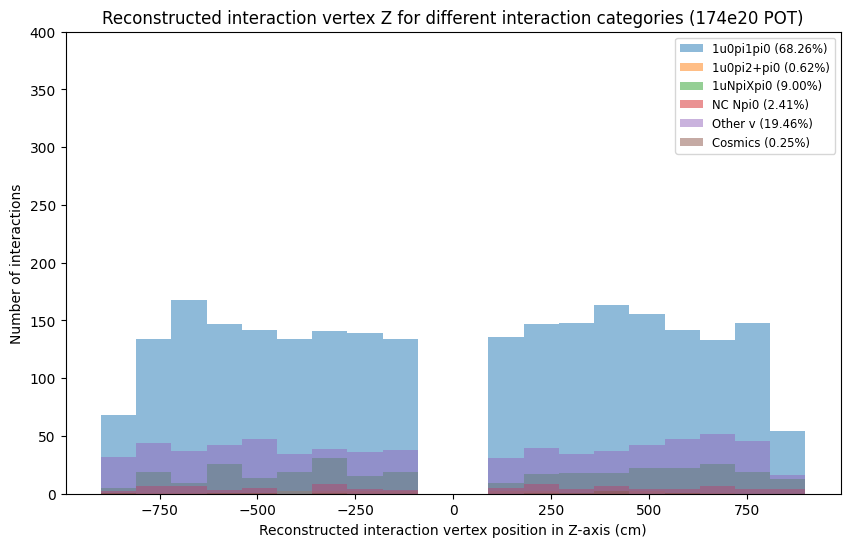

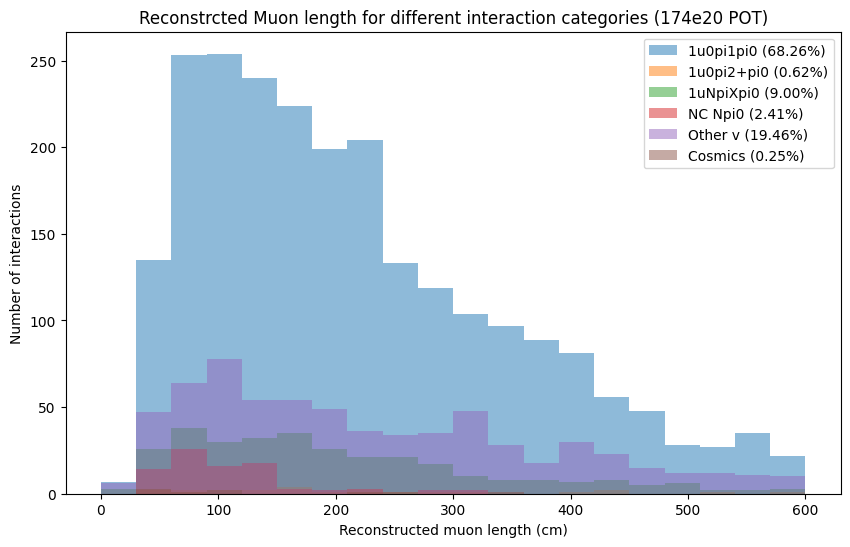

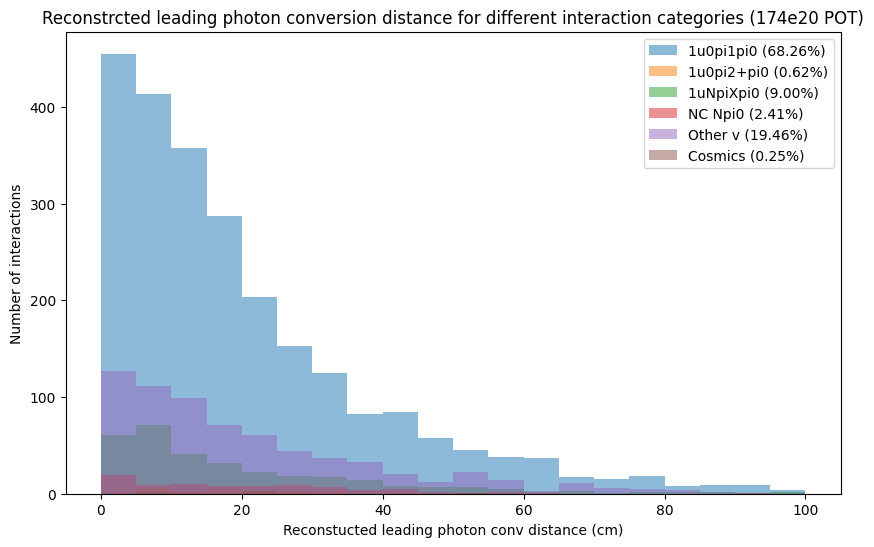

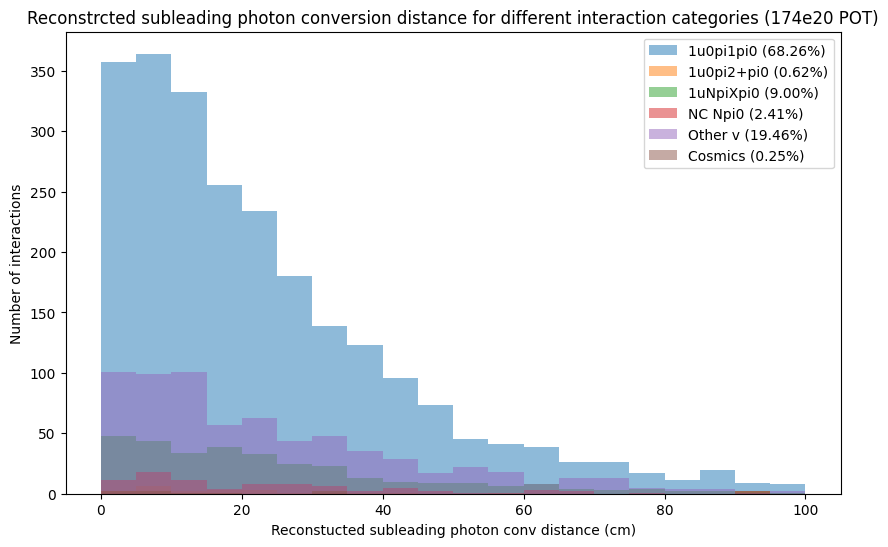

In [15]:
#BNB, input000.flat.root
#yy-shower truth selection 

#Importing relevant libraries
import numpy as np
import uproot
import pandas
import hist
import matplotlib.pyplot as plt

#enable this to see all outputs in a cell
#from IPython.core.interactiveshell import InteractiveShell
#InteractiveShell.ast_node_interactivity = "all"

#Opening the relevant ROOT file and tree
file = uproot.open(
    "e:/FYP/medulla_outputs/2_Shower_Selection_flashcut/NuMI_ccpi0ana_icarus_Jkoh1_initial_selection.root:events/NuMI_simulation/selected_nu"
)

#showing all TBranches
file.keys()

#Combining interaction category variable and reco vertex variables for easier analysis
combinedcategory = file.arrays(["true_category_topology_ccpi0_simple2","reco_vertex_x","reco_vertex_y","reco_vertex_z","reco_muon_length","reco_pi0_leading_shower_conv_dist","reco_pi0_subleading_shower_conv_dist"],library="pd")


#Splitting the interaction category variable into the relevant categories and grouping reco vertex variables according to the categories

#cosmics category: interactions that are not neutrino interactions (true_category_topology_ccpi0_simple2 is NaN)
cosmics_category = combinedcategory[combinedcategory["true_category_topology_ccpi0_simple2"].isna()]
print(f"Number of cosmic interactions and percentage: {len(cosmics_category)} out of {len(combinedcategory)} ({len(cosmics_category)/len(combinedcategory)*100:.2f}%)")

#neutrino 1mu1pi0 category: Neutrino interactions with 1 primary muon, 0 primary charged pions, and 1 primary neutral pion (true_category_topology_ccpi0_simple2 == 0)
neutrino_1mu0pi1pi0_category = combinedcategory[combinedcategory["true_category_topology_ccpi0_simple2"] == 0]
print(f"Number of 1mu0pi1pi0 CC neutrinointeractions and percentage: {len(neutrino_1mu0pi1pi0_category)} out of {len(combinedcategory)} ({len(neutrino_1mu0pi1pi0_category)/len(combinedcategory)*100:.2f}%)")

#neutrino 1mu0pi2pluspi0 category: Neutrino interactions with 1 primary muon, 0 primary charged pions, and 2 or more primary neutral pions (true_category_topology_ccpi0_simple2 == 1)
neutrino_1mu0pi2pluspi0_category = combinedcategory[combinedcategory["true_category_topology_ccpi0_simple2"] == 1]
print(f"Number of 1mu0pi2+pi0 CC neutrino interactions and percentage: {len(neutrino_1mu0pi2pluspi0_category)} out of {len(combinedcategory)} ({len(neutrino_1mu0pi2pluspi0_category)/len(combinedcategory)*100:.2f}%)")

#neutrino 1muNpiXpi0 category: Neutrino interactions with 1 primary muon, N primary charged pions (N>=1), and any number of primary neutral pions (true_category_topology_ccpi0_simple2 == 2)
neutrino_1muNpiXpi0_category = combinedcategory[combinedcategory["true_category_topology_ccpi0_simple2"] == 2]
print(f"Number of 1muNpiXpi0 CC neutrino interactions and percentage: {len(neutrino_1muNpiXpi0_category)} out of {len(combinedcategory)} ({len(neutrino_1muNpiXpi0_category)/len(combinedcategory)*100:.2f}%)")

#neutrino 0muNpi0 category: Neutrino interactions with 0 primary muons, N primary charged pions (N>=0), and any number of primary neutral pions (true_category_topology_ccpi0_simple2 == 3)
neutrino_0muNpi0_category = combinedcategory[combinedcategory["true_category_topology_ccpi0_simple2"] == 3]
print(f"Number of 0muNpi0 NC neutrino interactions and percentage: {len(neutrino_0muNpi0_category)} out of {len(combinedcategory)} ({len(neutrino_0muNpi0_category)/len(combinedcategory)*100:.2f}%)")

#neutrino othernu category: Neutrino interactions that do not fall into the above categories (true_category_topology_ccpi0_simple2 == 4)
neutrino_othernu_category = combinedcategory[combinedcategory["true_category_topology_ccpi0_simple2"] == 4]
print(f"Number of other neutrino interactions and percentage: {len(neutrino_othernu_category)} out of {len(combinedcategory)} ({len(neutrino_othernu_category)/len(combinedcategory)*100:.2f}%)")

#PLotting interaction vertex ===============================================================================

#Plotting the reco vertex x for each category into one histogram
plt.figure(figsize=(10,6))
plt.hist(neutrino_1mu0pi1pi0_category["reco_vertex_x"], bins=20, range=(-350, 350), alpha=0.5, label=f"1u0pi1pi0 ({len(neutrino_1mu0pi1pi0_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(neutrino_1mu0pi2pluspi0_category["reco_vertex_x"], bins=20, range=(-350, 350), alpha=0.5, label=f"1u0pi2+pi0 ({len(neutrino_1mu0pi2pluspi0_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(neutrino_1muNpiXpi0_category["reco_vertex_x"], bins=20, range=(-350, 350), alpha=0.5, label=f"1uNpiXpi0 ({len(neutrino_1muNpiXpi0_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(neutrino_0muNpi0_category["reco_vertex_x"], bins=20, range=(-350, 350), alpha=0.5, label=f"NC Npi0 ({len(neutrino_0muNpi0_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(neutrino_othernu_category["reco_vertex_x"], bins=20, range=(-350, 350), alpha=0.5, label=f"Other v ({len(neutrino_othernu_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(cosmics_category["reco_vertex_x"], bins=20, range=(-350, 350), alpha=0.5, label=f"Cosmics ({len(cosmics_category)/len(combinedcategory)*100:.2f}%)")
plt.legend()
plt.xlabel("Reconstructed interaction vertex position in X-axis (cm)")
plt.ylabel("Number of interactions")
plt.title(f"Reconstructed interaction vertex X for different interaction categories (174e20 POT)")

#Plotting the reco vertex y for each category into one histogram
plt.figure(figsize=(10,6))
plt.hist(neutrino_1mu0pi1pi0_category["reco_vertex_y"], bins=20, range=(-180, 140), alpha=0.5, label=f"1u0pi1pi0 ({len(neutrino_1mu0pi1pi0_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(neutrino_1mu0pi2pluspi0_category["reco_vertex_y"], bins=20, range=(-180, 140), alpha=0.5, label=f"1u0pi2+pi0 ({len(neutrino_1mu0pi2pluspi0_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(neutrino_1muNpiXpi0_category["reco_vertex_y"], bins=20, range=(-180, 140), alpha=0.5, label=f"1uNpiXpi0 ({len(neutrino_1muNpiXpi0_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(neutrino_0muNpi0_category["reco_vertex_y"], bins=20, range=(-180, 140), alpha=0.5, label=f"NC Npi0 ({len(neutrino_0muNpi0_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(neutrino_othernu_category["reco_vertex_y"], bins=20, range=(-180, 140), alpha=0.5, label=f"Other v ({len(neutrino_othernu_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(cosmics_category["reco_vertex_y"], bins=20, range=(-180, 140), alpha=0.5, label=f"Cosmics ({len(cosmics_category)/len(combinedcategory)*100:.2f}%)")
plt.legend()
plt.ylim(0,400)
plt.xlabel("Reconstructed interaction vertex position in Y-axis (cm)")
plt.ylabel("Number of interactions")
plt.title(f"Reconstructed interaction vertex Y for different interaction categories (174e20 POT)")

#Plotting the reco vertex z for each category into one histogram
plt.figure(figsize=(10,6))
plt.hist(neutrino_1mu0pi1pi0_category["reco_vertex_z"], bins=20, range=(-900, 900), alpha=0.5, label=f"1u0pi1pi0 ({len(neutrino_1mu0pi1pi0_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(neutrino_1mu0pi2pluspi0_category["reco_vertex_z"], bins=20, range=(-900, 900), alpha=0.5, label=f"1u0pi2+pi0 ({len(neutrino_1mu0pi2pluspi0_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(neutrino_1muNpiXpi0_category["reco_vertex_z"], bins=20, range=(-900, 900), alpha=0.5, label=f"1uNpiXpi0 ({len(neutrino_1muNpiXpi0_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(neutrino_0muNpi0_category["reco_vertex_z"], bins=20, range=(-900, 900), alpha=0.5, label=f"NC Npi0 ({len(neutrino_0muNpi0_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(neutrino_othernu_category["reco_vertex_z"], bins=20, range=(-900, 900), alpha=0.5, label=f"Other v ({len(neutrino_othernu_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(cosmics_category["reco_vertex_z"], bins=20, range=(-900, 900), alpha=0.5, label=f"Cosmics ({len(cosmics_category)/len(combinedcategory)*100:.2f}%)")
plt.legend(fontsize='small')
plt.ylim(0,400)
plt.xlabel("Reconstructed interaction vertex position in Z-axis (cm)")
plt.ylabel("Number of interactions")
plt.title(f"Reconstructed interaction vertex Z for different interaction categories (174e20 POT)")

#PLotting muon length ===============================================================================

plt.figure(figsize=(10,6))
plt.hist(neutrino_1mu0pi1pi0_category["reco_muon_length"], bins=20, range=(0, 600), alpha=0.5, label=f"1u0pi1pi0 ({len(neutrino_1mu0pi1pi0_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(neutrino_1mu0pi2pluspi0_category["reco_muon_length"], bins=20, range=(0, 600), alpha=0.5, label=f"1u0pi2+pi0 ({len(neutrino_1mu0pi2pluspi0_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(neutrino_1muNpiXpi0_category["reco_muon_length"], bins=20, range=(0, 600), alpha=0.5, label=f"1uNpiXpi0 ({len(neutrino_1muNpiXpi0_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(neutrino_0muNpi0_category["reco_muon_length"], bins=20, range=(0, 600), alpha=0.5, label=f"NC Npi0 ({len(neutrino_0muNpi0_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(neutrino_othernu_category["reco_muon_length"], bins=20, range=(0, 600), alpha=0.5, label=f"Other v ({len(neutrino_othernu_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(cosmics_category["reco_muon_length"], bins=20, range=(0, 600), alpha=0.5, label=f"Cosmics ({len(cosmics_category)/len(combinedcategory)*100:.2f}%)")
plt.legend()
plt.xlabel("Reconstructed muon length (cm)")
plt.ylabel("Number of interactions")
plt.title(f"Reconstrcted Muon length for different interaction categories (174e20 POT)")

#Plotting shower conversion distance ===============================================================================

#PLotting leading shower conversion distance
plt.figure(figsize=(10,6))
plt.hist(neutrino_1mu0pi1pi0_category["reco_pi0_leading_shower_conv_dist"], bins=20, range=(0, 100), alpha=0.5, label=f"1u0pi1pi0 ({len(neutrino_1mu0pi1pi0_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(neutrino_1mu0pi2pluspi0_category["reco_pi0_leading_shower_conv_dist"], bins=20, range=(0, 100), alpha=0.5, label=f"1u0pi2+pi0 ({len(neutrino_1mu0pi2pluspi0_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(neutrino_1muNpiXpi0_category["reco_pi0_leading_shower_conv_dist"], bins=20, range=(0, 100), alpha=0.5, label=f"1uNpiXpi0 ({len(neutrino_1muNpiXpi0_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(neutrino_0muNpi0_category["reco_pi0_leading_shower_conv_dist"], bins=20, range=(0, 100), alpha=0.5, label=f"NC Npi0 ({len(neutrino_0muNpi0_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(neutrino_othernu_category["reco_pi0_leading_shower_conv_dist"], bins=20, range=(0, 100), alpha=0.5, label=f"Other v ({len(neutrino_othernu_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(cosmics_category["reco_pi0_leading_shower_conv_dist"], bins=20, range=(0, 100), alpha=0.5, label=f"Cosmics ({len(cosmics_category)/len(combinedcategory)*100:.2f}%)")
plt.legend()
plt.xlabel("Reconstucted leading photon conv distance (cm)")
plt.ylabel("Number of interactions")
plt.title(f"Reconstrcted leading photon conversion distance for different interaction categories (174e20 POT)")

#PLotting leading shower conversion distance
plt.figure(figsize=(10,6))
plt.hist(neutrino_1mu0pi1pi0_category["reco_pi0_subleading_shower_conv_dist"], bins=20, range=(0, 100), alpha=0.5, label=f"1u0pi1pi0 ({len(neutrino_1mu0pi1pi0_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(neutrino_1mu0pi2pluspi0_category["reco_pi0_subleading_shower_conv_dist"], bins=20, range=(0, 100), alpha=0.5, label=f"1u0pi2+pi0 ({len(neutrino_1mu0pi2pluspi0_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(neutrino_1muNpiXpi0_category["reco_pi0_subleading_shower_conv_dist"], bins=20, range=(0, 100), alpha=0.5, label=f"1uNpiXpi0 ({len(neutrino_1muNpiXpi0_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(neutrino_0muNpi0_category["reco_pi0_subleading_shower_conv_dist"], bins=20, range=(0, 100), alpha=0.5, label=f"NC Npi0 ({len(neutrino_0muNpi0_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(neutrino_othernu_category["reco_pi0_subleading_shower_conv_dist"], bins=20, range=(0, 100), alpha=0.5, label=f"Other v ({len(neutrino_othernu_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(cosmics_category["reco_pi0_subleading_shower_conv_dist"], bins=20, range=(0, 100), alpha=0.5, label=f"Cosmics ({len(cosmics_category)/len(combinedcategory)*100:.2f}%)")
plt.legend()
plt.xlabel("Reconstucted subleading photon conv distance (cm)")
plt.ylabel("Number of interactions")
plt.title(f"Reconstrcted subleading photon conversion distance for different interaction categories (174e20 POT)")


<h2 style="font-size: 24px;">1.6.2 Transverse kinematic imbalance Observables</h2>

Number of cosmic interactions and percentage: 9 out of 3566 (0.25%)
Number of 1mu0pi1pi0 CC neutrinointeractions and percentage: 2434 out of 3566 (68.26%)
Number of 1mu0pi2+pi0 CC neutrino interactions and percentage: 22 out of 3566 (0.62%)
Number of 1muNpiXpi0 CC neutrino interactions and percentage: 321 out of 3566 (9.00%)
Number of 0muNpi0 NC neutrino interactions and percentage: 86 out of 3566 (2.41%)
Number of other neutrino interactions and percentage: 694 out of 3566 (19.46%)


Text(0.5, 1.0, 'Reconstructed transverse momentum for different interaction categories (174e20 POT)')

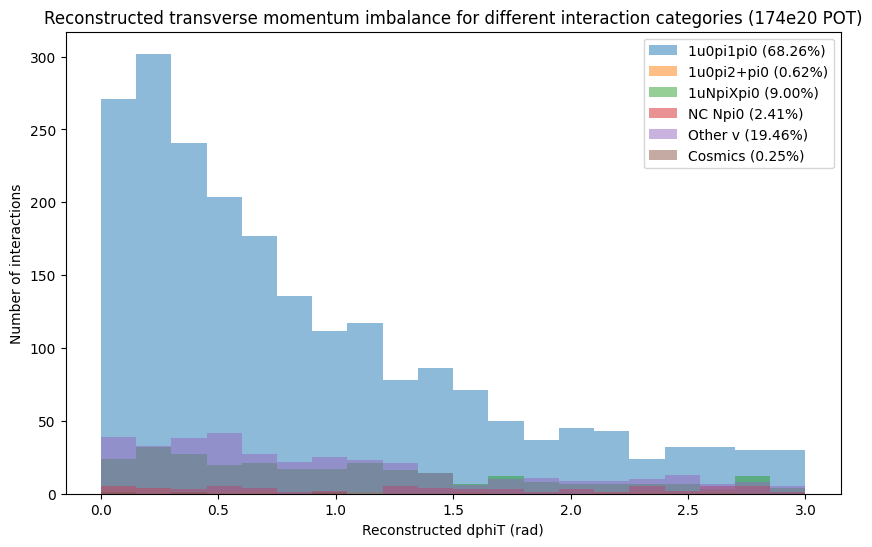

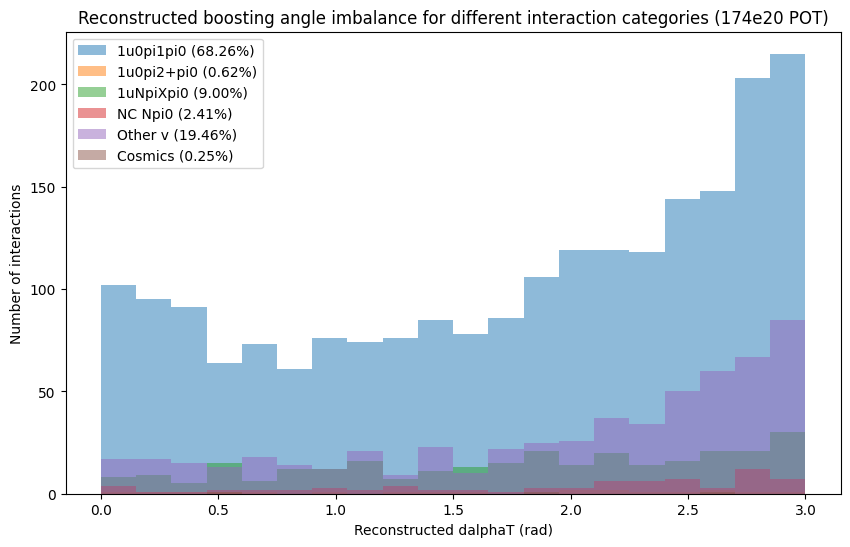

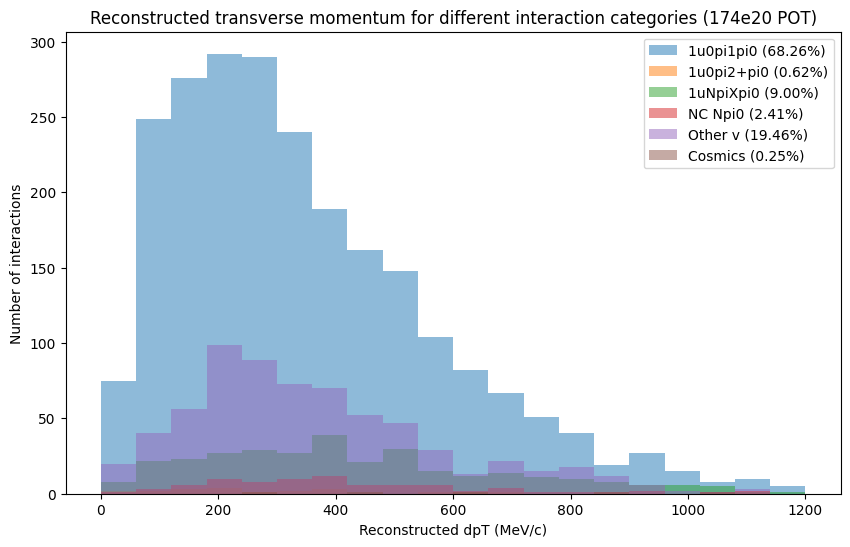

In [31]:
#BNB, input000.flat.root
#yy-shower truth selection 

#Importing relevant libraries
import numpy as np
import uproot
import pandas
import hist
import matplotlib.pyplot as plt

#enable this to see all outputs in a cell
#from IPython.core.interactiveshell import InteractiveShell
#InteractiveShell.ast_node_interactivity = "all"

#Opening the relevant ROOT file and tree
file = uproot.open(
    "e:/FYP/medulla_outputs/2_Shower_Selection_flashcut/NuMI_ccpi0ana_icarus_Jkoh1_initial_selection.root:events/NuMI_simulation/selected_nu"
)

#showing all TBranches
file.keys()

#Combining interaction category variable and reco vertex variables for easier analysis
combinedcategory = file.arrays(["true_category_topology_ccpi0_simple2","reco_dphiT","reco_dalphaT","reco_dpT"],library="pd")


#Splitting the interaction category variable into the relevant categories and grouping reco vertex variables according to the categories

#cosmics category: interactions that are not neutrino interactions (true_category_topology_ccpi0_simple2 is NaN)
cosmics_category = combinedcategory[combinedcategory["true_category_topology_ccpi0_simple2"].isna()]
print(f"Number of cosmic interactions and percentage: {len(cosmics_category)} out of {len(combinedcategory)} ({len(cosmics_category)/len(combinedcategory)*100:.2f}%)")

#neutrino 1mu1pi0 category: Neutrino interactions with 1 primary muon, 0 primary charged pions, and 1 primary neutral pion (true_category_topology_ccpi0_simple2 == 0)
neutrino_1mu0pi1pi0_category = combinedcategory[combinedcategory["true_category_topology_ccpi0_simple2"] == 0]
print(f"Number of 1mu0pi1pi0 CC neutrinointeractions and percentage: {len(neutrino_1mu0pi1pi0_category)} out of {len(combinedcategory)} ({len(neutrino_1mu0pi1pi0_category)/len(combinedcategory)*100:.2f}%)")

#neutrino 1mu0pi2pluspi0 category: Neutrino interactions with 1 primary muon, 0 primary charged pions, and 2 or more primary neutral pions (true_category_topology_ccpi0_simple2 == 1)
neutrino_1mu0pi2pluspi0_category = combinedcategory[combinedcategory["true_category_topology_ccpi0_simple2"] == 1]
print(f"Number of 1mu0pi2+pi0 CC neutrino interactions and percentage: {len(neutrino_1mu0pi2pluspi0_category)} out of {len(combinedcategory)} ({len(neutrino_1mu0pi2pluspi0_category)/len(combinedcategory)*100:.2f}%)")

#neutrino 1muNpiXpi0 category: Neutrino interactions with 1 primary muon, N primary charged pions (N>=1), and any number of primary neutral pions (true_category_topology_ccpi0_simple2 == 2)
neutrino_1muNpiXpi0_category = combinedcategory[combinedcategory["true_category_topology_ccpi0_simple2"] == 2]
print(f"Number of 1muNpiXpi0 CC neutrino interactions and percentage: {len(neutrino_1muNpiXpi0_category)} out of {len(combinedcategory)} ({len(neutrino_1muNpiXpi0_category)/len(combinedcategory)*100:.2f}%)")

#neutrino 0muNpi0 category: Neutrino interactions with 0 primary muons, N primary charged pions (N>=0), and any number of primary neutral pions (true_category_topology_ccpi0_simple2 == 3)
neutrino_0muNpi0_category = combinedcategory[combinedcategory["true_category_topology_ccpi0_simple2"] == 3]
print(f"Number of 0muNpi0 NC neutrino interactions and percentage: {len(neutrino_0muNpi0_category)} out of {len(combinedcategory)} ({len(neutrino_0muNpi0_category)/len(combinedcategory)*100:.2f}%)")

#neutrino othernu category: Neutrino interactions that do not fall into the above categories (true_category_topology_ccpi0_simple2 == 4)
neutrino_othernu_category = combinedcategory[combinedcategory["true_category_topology_ccpi0_simple2"] == 4]
print(f"Number of other neutrino interactions and percentage: {len(neutrino_othernu_category)} out of {len(combinedcategory)} ({len(neutrino_othernu_category)/len(combinedcategory)*100:.2f}%)")

#PLotting transverse kinematic imbalance variables ===============================================================================

#Plotting the tranverse momentum imbalance for each category into one histogram
plt.figure(figsize=(10,6))
plt.hist(neutrino_1mu0pi1pi0_category["reco_dphiT"], bins=20, range=(0, 3), alpha=0.5, label=f"1u0pi1pi0 ({len(neutrino_1mu0pi1pi0_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(neutrino_1mu0pi2pluspi0_category["reco_dphiT"], bins=20, range=(0, 3), alpha=0.5, label=f"1u0pi2+pi0 ({len(neutrino_1mu0pi2pluspi0_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(neutrino_1muNpiXpi0_category["reco_dphiT"], bins=20, range=(0, 3), alpha=0.5, label=f"1uNpiXpi0 ({len(neutrino_1muNpiXpi0_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(neutrino_0muNpi0_category["reco_dphiT"], bins=20, range=(0, 3), alpha=0.5, label=f"NC Npi0 ({len(neutrino_0muNpi0_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(neutrino_othernu_category["reco_dphiT"], bins=20, range=(0, 3), alpha=0.5, label=f"Other v ({len(neutrino_othernu_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(cosmics_category["reco_dphiT"], bins=20, range=(0, 3), alpha=0.5, label=f"Cosmics ({len(cosmics_category)/len(combinedcategory)*100:.2f}%)")
plt.legend()
plt.xlabel("Reconstructed dphiT (rad)")
plt.ylabel("Number of interactions")
plt.title(f"Reconstructed transverse momentum imbalance for different interaction categories (174e20 POT)")

#Plotting the boosting angle for each category into one histogram
plt.figure(figsize=(10,6))
plt.hist(neutrino_1mu0pi1pi0_category["reco_dalphaT"], bins=20, range=(0, 3), alpha=0.5, label=f"1u0pi1pi0 ({len(neutrino_1mu0pi1pi0_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(neutrino_1mu0pi2pluspi0_category["reco_dalphaT"], bins=20, range=(0, 3), alpha=0.5, label=f"1u0pi2+pi0 ({len(neutrino_1mu0pi2pluspi0_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(neutrino_1muNpiXpi0_category["reco_dalphaT"], bins=20, range=(0, 3), alpha=0.5, label=f"1uNpiXpi0 ({len(neutrino_1muNpiXpi0_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(neutrino_0muNpi0_category["reco_dalphaT"], bins=20, range=(0, 3), alpha=0.5, label=f"NC Npi0 ({len(neutrino_0muNpi0_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(neutrino_othernu_category["reco_dalphaT"], bins=20, range=(0, 3), alpha=0.5, label=f"Other v ({len(neutrino_othernu_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(cosmics_category["reco_dalphaT"], bins=20, range=(0, 3), alpha=0.5, label=f"Cosmics ({len(cosmics_category)/len(combinedcategory)*100:.2f}%)")
plt.legend()
plt.xlabel("Reconstructed dalphaT (rad)")
plt.ylabel("Number of interactions")
plt.title(f"Reconstructed boosting angle imbalance for different interaction categories (174e20 POT)")

#Plotting the tranverse momentum  for each category into one histogram
plt.figure(figsize=(10,6))
plt.hist(neutrino_1mu0pi1pi0_category["reco_dpT"], bins=20, range=(0, 1200), alpha=0.5, label=f"1u0pi1pi0 ({len(neutrino_1mu0pi1pi0_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(neutrino_1mu0pi2pluspi0_category["reco_dpT"], bins=20, range=(0, 1200), alpha=0.5, label=f"1u0pi2+pi0 ({len(neutrino_1mu0pi2pluspi0_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(neutrino_1muNpiXpi0_category["reco_dpT"], bins=20, range=(0, 1200), alpha=0.5, label=f"1uNpiXpi0 ({len(neutrino_1muNpiXpi0_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(neutrino_0muNpi0_category["reco_dpT"], bins=20, range=(0, 1200), alpha=0.5, label=f"NC Npi0 ({len(neutrino_0muNpi0_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(neutrino_othernu_category["reco_dpT"], bins=20, range=(0, 1200), alpha=0.5, label=f"Other v ({len(neutrino_othernu_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(cosmics_category["reco_dpT"], bins=20, range=(0, 1200), alpha=0.5, label=f"Cosmics ({len(cosmics_category)/len(combinedcategory)*100:.2f}%)")
plt.legend()
plt.xlabel("Reconstructed dpT (MeV/c)")
plt.ylabel("Number of interactions")
plt.title(f"Reconstructed transverse momentum for different interaction categories (174e20 POT)")






<h2 style="font-size: 24px;">1.6.3 Four-Momentum Transfer and Hadronic Invariant Mass</h2>

Number of cosmic interactions and percentage: 9 out of 3566 (0.25%)
Number of 1mu0pi1pi0 CC neutrinointeractions and percentage: 2434 out of 3566 (68.26%)
Number of 1mu0pi2+pi0 CC neutrino interactions and percentage: 22 out of 3566 (0.62%)
Number of 1muNpiXpi0 CC neutrino interactions and percentage: 321 out of 3566 (9.00%)
Number of 0muNpi0 NC neutrino interactions and percentage: 86 out of 3566 (2.41%)
Number of other neutrino interactions and percentage: 694 out of 3566 (19.46%)


Text(0.5, 1.0, 'Reconstructed Final state hadronic invariant mass for different interaction categories (174e20 POT)')

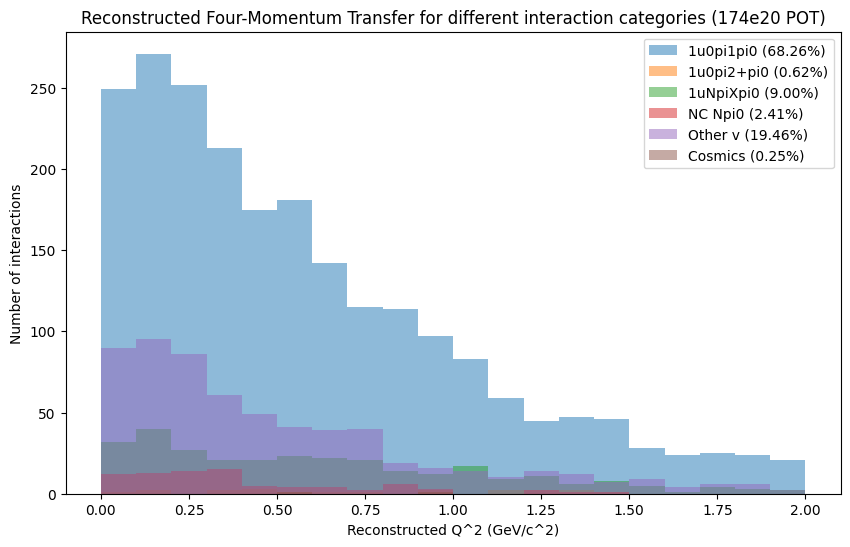

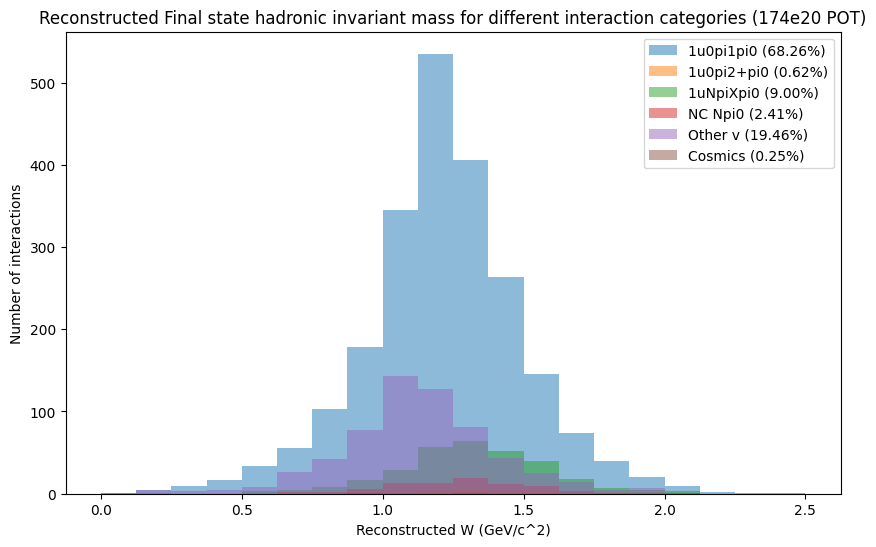

In [32]:
#BNB, input000.flat.root
#yy-shower truth selection 

#Importing relevant libraries
import numpy as np
import uproot
import pandas
import hist
import matplotlib.pyplot as plt

#enable this to see all outputs in a cell
#from IPython.core.interactiveshell import InteractiveShell
#InteractiveShell.ast_node_interactivity = "all"

#Opening the relevant ROOT file and tree
file = uproot.open(
    "e:/FYP/medulla_outputs/2_Shower_Selection_flashcut/NuMI_ccpi0ana_icarus_Jkoh1_initial_selection.root:events/NuMI_simulation/selected_nu"
)

#showing all TBranches
file.keys()

#Combining interaction category variable and reco vertex variables for easier analysis
combinedcategory = file.arrays(["true_category_topology_ccpi0_simple2","reco_Q2","reco_W"],library="pd")


#Splitting the interaction category variable into the relevant categories and grouping reco vertex variables according to the categories

#cosmics category: interactions that are not neutrino interactions (true_category_topology_ccpi0_simple2 is NaN)
cosmics_category = combinedcategory[combinedcategory["true_category_topology_ccpi0_simple2"].isna()]
print(f"Number of cosmic interactions and percentage: {len(cosmics_category)} out of {len(combinedcategory)} ({len(cosmics_category)/len(combinedcategory)*100:.2f}%)")

#neutrino 1mu1pi0 category: Neutrino interactions with 1 primary muon, 0 primary charged pions, and 1 primary neutral pion (true_category_topology_ccpi0_simple2 == 0)
neutrino_1mu0pi1pi0_category = combinedcategory[combinedcategory["true_category_topology_ccpi0_simple2"] == 0]
print(f"Number of 1mu0pi1pi0 CC neutrinointeractions and percentage: {len(neutrino_1mu0pi1pi0_category)} out of {len(combinedcategory)} ({len(neutrino_1mu0pi1pi0_category)/len(combinedcategory)*100:.2f}%)")

#neutrino 1mu0pi2pluspi0 category: Neutrino interactions with 1 primary muon, 0 primary charged pions, and 2 or more primary neutral pions (true_category_topology_ccpi0_simple2 == 1)
neutrino_1mu0pi2pluspi0_category = combinedcategory[combinedcategory["true_category_topology_ccpi0_simple2"] == 1]
print(f"Number of 1mu0pi2+pi0 CC neutrino interactions and percentage: {len(neutrino_1mu0pi2pluspi0_category)} out of {len(combinedcategory)} ({len(neutrino_1mu0pi2pluspi0_category)/len(combinedcategory)*100:.2f}%)")

#neutrino 1muNpiXpi0 category: Neutrino interactions with 1 primary muon, N primary charged pions (N>=1), and any number of primary neutral pions (true_category_topology_ccpi0_simple2 == 2)
neutrino_1muNpiXpi0_category = combinedcategory[combinedcategory["true_category_topology_ccpi0_simple2"] == 2]
print(f"Number of 1muNpiXpi0 CC neutrino interactions and percentage: {len(neutrino_1muNpiXpi0_category)} out of {len(combinedcategory)} ({len(neutrino_1muNpiXpi0_category)/len(combinedcategory)*100:.2f}%)")

#neutrino 0muNpi0 category: Neutrino interactions with 0 primary muons, N primary charged pions (N>=0), and any number of primary neutral pions (true_category_topology_ccpi0_simple2 == 3)
neutrino_0muNpi0_category = combinedcategory[combinedcategory["true_category_topology_ccpi0_simple2"] == 3]
print(f"Number of 0muNpi0 NC neutrino interactions and percentage: {len(neutrino_0muNpi0_category)} out of {len(combinedcategory)} ({len(neutrino_0muNpi0_category)/len(combinedcategory)*100:.2f}%)")

#neutrino othernu category: Neutrino interactions that do not fall into the above categories (true_category_topology_ccpi0_simple2 == 4)
neutrino_othernu_category = combinedcategory[combinedcategory["true_category_topology_ccpi0_simple2"] == 4]
print(f"Number of other neutrino interactions and percentage: {len(neutrino_othernu_category)} out of {len(combinedcategory)} ({len(neutrino_othernu_category)/len(combinedcategory)*100:.2f}%)")

#PLotting Four-Momentum Transfer and Hadronic Invariant Mass variables ===============================================================================

#Plotting the Four-Momentum Transfer for each category into one histogram
plt.figure(figsize=(10,6))
plt.hist(neutrino_1mu0pi1pi0_category["reco_Q2"], bins=20, range=(0, 2), alpha=0.5, label=f"1u0pi1pi0 ({len(neutrino_1mu0pi1pi0_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(neutrino_1mu0pi2pluspi0_category["reco_Q2"], bins=20, range=(0, 2), alpha=0.5, label=f"1u0pi2+pi0 ({len(neutrino_1mu0pi2pluspi0_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(neutrino_1muNpiXpi0_category["reco_Q2"], bins=20, range=(0, 2), alpha=0.5, label=f"1uNpiXpi0 ({len(neutrino_1muNpiXpi0_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(neutrino_0muNpi0_category["reco_Q2"], bins=20, range=(0, 2), alpha=0.5, label=f"NC Npi0 ({len(neutrino_0muNpi0_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(neutrino_othernu_category["reco_Q2"], bins=20, range=(0, 2), alpha=0.5, label=f"Other v ({len(neutrino_othernu_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(cosmics_category["reco_Q2"], bins=20, range=(0, 2), alpha=0.5, label=f"Cosmics ({len(cosmics_category)/len(combinedcategory)*100:.2f}%)")
plt.legend()
plt.xlabel("Reconstructed Q^2 (GeV/c^2)")
plt.ylabel("Number of interactions")
plt.title(f"Reconstructed Four-Momentum Transfer for different interaction categories (174e20 POT)")

#Plotting the hadronic invariant mass for each category into one histogram
plt.figure(figsize=(10,6))
plt.hist(neutrino_1mu0pi1pi0_category["reco_W"], bins=20, range=(0, 2.5), alpha=0.5, label=f"1u0pi1pi0 ({len(neutrino_1mu0pi1pi0_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(neutrino_1mu0pi2pluspi0_category["reco_W"], bins=20, range=(0, 2.5), alpha=0.5, label=f"1u0pi2+pi0 ({len(neutrino_1mu0pi2pluspi0_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(neutrino_1muNpiXpi0_category["reco_W"], bins=20, range=(0, 2.5), alpha=0.5, label=f"1uNpiXpi0 ({len(neutrino_1muNpiXpi0_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(neutrino_0muNpi0_category["reco_W"], bins=20, range=(0, 2.5), alpha=0.5, label=f"NC Npi0 ({len(neutrino_0muNpi0_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(neutrino_othernu_category["reco_W"], bins=20, range=(0, 2.5), alpha=0.5, label=f"Other v ({len(neutrino_othernu_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(cosmics_category["reco_W"], bins=20, range=(0, 2.5), alpha=0.5, label=f"Cosmics ({len(cosmics_category)/len(combinedcategory)*100:.2f}%)")
plt.legend()
plt.xlabel("Reconstructed W (GeV/c^2)")
plt.ylabel("Number of interactions")
plt.title(f"Reconstructed Final state hadronic invariant mass for different interaction categories (174e20 POT)")


<h2 style="font-size: 24px;">1.6.4 Neutral pion mass Observables</h2>

Number of cosmic interactions and percentage: 9 out of 3566 (0.25%)
Number of 1mu0pi1pi0 CC neutrinointeractions and percentage: 2434 out of 3566 (68.26%)
Number of 1mu0pi2+pi0 CC neutrino interactions and percentage: 22 out of 3566 (0.62%)
Number of 1muNpiXpi0 CC neutrino interactions and percentage: 321 out of 3566 (9.00%)
Number of 0muNpi0 NC neutrino interactions and percentage: 86 out of 3566 (2.41%)
Number of other neutrino interactions and percentage: 694 out of 3566 (19.46%)


Text(0, 0.5, 'Fraction of interactions')

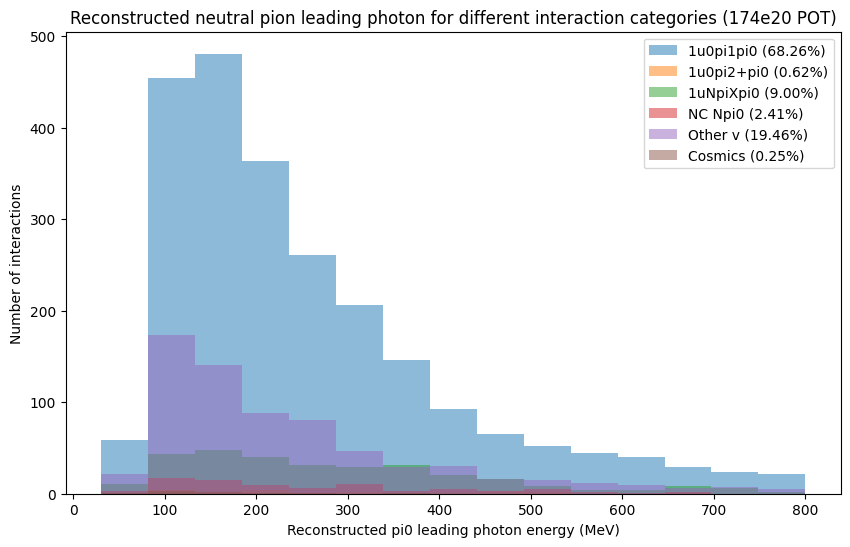

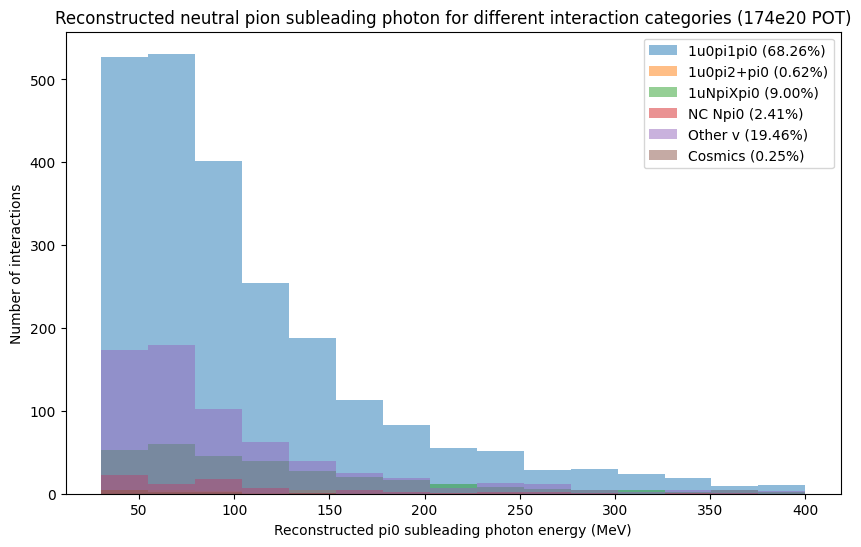

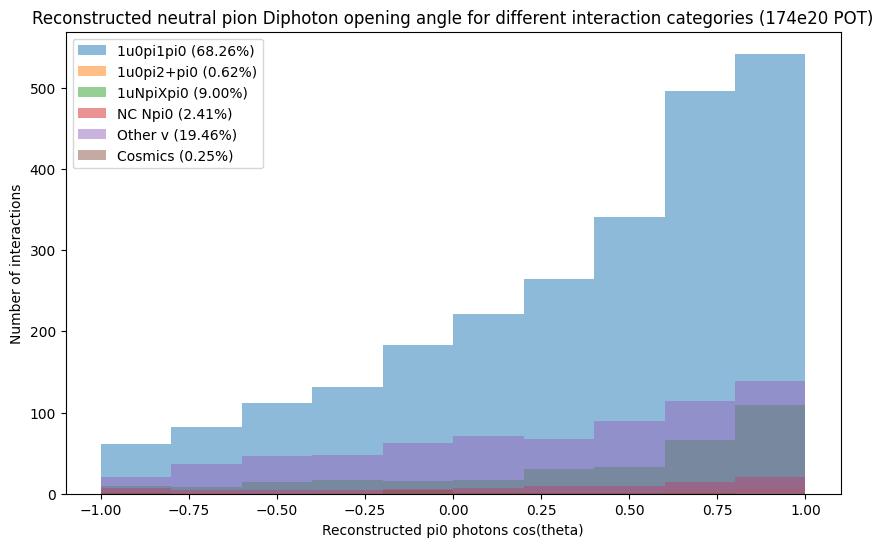

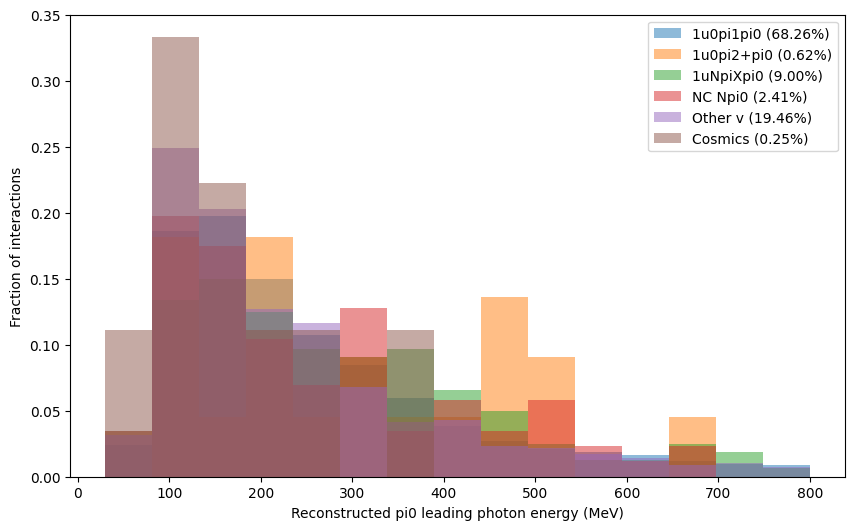

In [ ]:
#BNB, input000.flat.root
#yy-shower truth selection 

#Importing relevant libraries
import numpy as np
import uproot
import pandas
import hist
import matplotlib.pyplot as plt

#enable this to see all outputs in a cell
#from IPython.core.interactiveshell import InteractiveShell
#InteractiveShell.ast_node_interactivity = "all"

#Opening the relevant ROOT file and tree
file = uproot.open(
    "e:/FYP/medulla_outputs/2_Shower_Selection_flashcut/NuMI_ccpi0ana_icarus_Jkoh1_initial_selection.root:events/NuMI_simulation/selected_nu"
)

#showing all TBranches
file.keys()

#Combining interaction category variable and reco vertex variables for easier analysis
combinedcategory = file.arrays(["true_category_topology_ccpi0_simple2","reco_pi0_leading_shower_ke","reco_pi0_subleading_shower_ke","reco_pi0_showers_costheta"],library="pd")


#Splitting the interaction category variable into the relevant categories and grouping reco vertex variables according to the categories

#cosmics category: interactions that are not neutrino interactions (true_category_topology_ccpi0_simple2 is NaN)
cosmics_category = combinedcategory[combinedcategory["true_category_topology_ccpi0_simple2"].isna()]
print(f"Number of cosmic interactions and percentage: {len(cosmics_category)} out of {len(combinedcategory)} ({len(cosmics_category)/len(combinedcategory)*100:.2f}%)")

#neutrino 1mu1pi0 category: Neutrino interactions with 1 primary muon, 0 primary charged pions, and 1 primary neutral pion (true_category_topology_ccpi0_simple2 == 0)
neutrino_1mu0pi1pi0_category = combinedcategory[combinedcategory["true_category_topology_ccpi0_simple2"] == 0]
print(f"Number of 1mu0pi1pi0 CC neutrinointeractions and percentage: {len(neutrino_1mu0pi1pi0_category)} out of {len(combinedcategory)} ({len(neutrino_1mu0pi1pi0_category)/len(combinedcategory)*100:.2f}%)")

#neutrino 1mu0pi2pluspi0 category: Neutrino interactions with 1 primary muon, 0 primary charged pions, and 2 or more primary neutral pions (true_category_topology_ccpi0_simple2 == 1)
neutrino_1mu0pi2pluspi0_category = combinedcategory[combinedcategory["true_category_topology_ccpi0_simple2"] == 1]
print(f"Number of 1mu0pi2+pi0 CC neutrino interactions and percentage: {len(neutrino_1mu0pi2pluspi0_category)} out of {len(combinedcategory)} ({len(neutrino_1mu0pi2pluspi0_category)/len(combinedcategory)*100:.2f}%)")

#neutrino 1muNpiXpi0 category: Neutrino interactions with 1 primary muon, N primary charged pions (N>=1), and any number of primary neutral pions (true_category_topology_ccpi0_simple2 == 2)
neutrino_1muNpiXpi0_category = combinedcategory[combinedcategory["true_category_topology_ccpi0_simple2"] == 2]
print(f"Number of 1muNpiXpi0 CC neutrino interactions and percentage: {len(neutrino_1muNpiXpi0_category)} out of {len(combinedcategory)} ({len(neutrino_1muNpiXpi0_category)/len(combinedcategory)*100:.2f}%)")

#neutrino 0muNpi0 category: Neutrino interactions with 0 primary muons, N primary charged pions (N>=0), and any number of primary neutral pions (true_category_topology_ccpi0_simple2 == 3)
neutrino_0muNpi0_category = combinedcategory[combinedcategory["true_category_topology_ccpi0_simple2"] == 3]
print(f"Number of 0muNpi0 NC neutrino interactions and percentage: {len(neutrino_0muNpi0_category)} out of {len(combinedcategory)} ({len(neutrino_0muNpi0_category)/len(combinedcategory)*100:.2f}%)")

#neutrino othernu category: Neutrino interactions that do not fall into the above categories (true_category_topology_ccpi0_simple2 == 4)
neutrino_othernu_category = combinedcategory[combinedcategory["true_category_topology_ccpi0_simple2"] == 4]
print(f"Number of other neutrino interactions and percentage: {len(neutrino_othernu_category)} out of {len(combinedcategory)} ({len(neutrino_othernu_category)/len(combinedcategory)*100:.2f}%)")

#PLotting neutral pion mass variables ===============================================================================

#Plotting the leading shower ke for each category into one histogram
plt.figure(figsize=(10,6))
plt.hist(neutrino_1mu0pi1pi0_category["reco_pi0_leading_shower_ke"], bins=15, range=(30, 800), alpha=0.5, label=f"1u0pi1pi0 ({len(neutrino_1mu0pi1pi0_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(neutrino_1mu0pi2pluspi0_category["reco_pi0_leading_shower_ke"], bins=15, range=(30, 800), alpha=0.5, label=f"1u0pi2+pi0 ({len(neutrino_1mu0pi2pluspi0_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(neutrino_1muNpiXpi0_category["reco_pi0_leading_shower_ke"], bins=15, range=(30, 800), alpha=0.5, label=f"1uNpiXpi0 ({len(neutrino_1muNpiXpi0_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(neutrino_0muNpi0_category["reco_pi0_leading_shower_ke"], bins=15, range=(30, 800), alpha=0.5, label=f"NC Npi0 ({len(neutrino_0muNpi0_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(neutrino_othernu_category["reco_pi0_leading_shower_ke"], bins=15, range=(30, 800), alpha=0.5, label=f"Other v ({len(neutrino_othernu_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(cosmics_category["reco_pi0_leading_shower_ke"], bins=15, range=(30, 800), alpha=0.5, label=f"Cosmics ({len(cosmics_category)/len(combinedcategory)*100:.2f}%)")
plt.legend()
plt.xlabel("Reconstructed pi0 leading photon energy (MeV)")
plt.ylabel("Number of interactions")
plt.title(f"Reconstructed neutral pion leading photon for different interaction categories (174e20 POT)")

#Plotting the subleading shower ke for each category into one histogram
plt.figure(figsize=(10,6))
plt.hist(neutrino_1mu0pi1pi0_category["reco_pi0_subleading_shower_ke"], bins=15, range=(30, 400), alpha=0.5, label=f"1u0pi1pi0 ({len(neutrino_1mu0pi1pi0_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(neutrino_1mu0pi2pluspi0_category["reco_pi0_subleading_shower_ke"], bins=15, range=(30, 400), alpha=0.5, label=f"1u0pi2+pi0 ({len(neutrino_1mu0pi2pluspi0_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(neutrino_1muNpiXpi0_category["reco_pi0_subleading_shower_ke"], bins=15, range=(30, 400), alpha=0.5, label=f"1uNpiXpi0 ({len(neutrino_1muNpiXpi0_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(neutrino_0muNpi0_category["reco_pi0_subleading_shower_ke"], bins=15, range=(30, 400), alpha=0.5, label=f"NC Npi0 ({len(neutrino_0muNpi0_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(neutrino_othernu_category["reco_pi0_subleading_shower_ke"], bins=15, range=(30, 400), alpha=0.5, label=f"Other v ({len(neutrino_othernu_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(cosmics_category["reco_pi0_subleading_shower_ke"], bins=15, range=(30, 400), alpha=0.5, label=f"Cosmics ({len(cosmics_category)/len(combinedcategory)*100:.2f}%)")
plt.legend()
plt.xlabel("Reconstructed pi0 subleading photon energy (MeV)")
plt.ylabel("Number of interactions")
plt.title(f"Reconstructed neutral pion subleading photon for different interaction categories (174e20 POT)")

#Plotting the Diphoton opening angle for each category into one histogram
plt.figure(figsize=(10,6))
plt.hist(neutrino_1mu0pi1pi0_category["reco_pi0_showers_costheta"], bins=10, range=(-1, 1), alpha=0.5, label=f"1u0pi1pi0 ({len(neutrino_1mu0pi1pi0_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(neutrino_1mu0pi2pluspi0_category["reco_pi0_showers_costheta"], bins=10, range=(-1, 1), alpha=0.5, label=f"1u0pi2+pi0 ({len(neutrino_1mu0pi2pluspi0_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(neutrino_1muNpiXpi0_category["reco_pi0_showers_costheta"], bins=10, range=(-1, 1), alpha=0.5, label=f"1uNpiXpi0 ({len(neutrino_1muNpiXpi0_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(neutrino_0muNpi0_category["reco_pi0_showers_costheta"], bins=10, range=(-1, 1), alpha=0.5, label=f"NC Npi0 ({len(neutrino_0muNpi0_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(neutrino_othernu_category["reco_pi0_showers_costheta"], bins=10, range=(-1, 1), alpha=0.5, label=f"Other v ({len(neutrino_othernu_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(cosmics_category["reco_pi0_showers_costheta"], bins=10, range=(-1, 1), alpha=0.5, label=f"Cosmics ({len(cosmics_category)/len(combinedcategory)*100:.2f}%)")
plt.legend()
plt.xlabel("Reconstructed pi0 photons cos(theta)")
plt.ylabel("Number of interactions")
plt.title(f"Reconstructed neutral pion Diphoton opening angle for different interaction categories (174e20 POT)")




<h2 style="font-size: 24px;">1.6.5 Cross Section Analysis Observables</h2>

Number of cosmic interactions and percentage: 9 out of 3566 (0.25%)
Number of 1mu0pi1pi0 CC neutrinointeractions and percentage: 2434 out of 3566 (68.26%)
Number of 1mu0pi2+pi0 CC neutrino interactions and percentage: 22 out of 3566 (0.62%)
Number of 1muNpiXpi0 CC neutrino interactions and percentage: 321 out of 3566 (9.00%)
Number of 0muNpi0 NC neutrino interactions and percentage: 86 out of 3566 (2.41%)
Number of other neutrino interactions and percentage: 694 out of 3566 (19.46%)


Text(0.5, 1.0, 'Reconstructed pi0 costheta for different interaction categories (174e20 POT)')

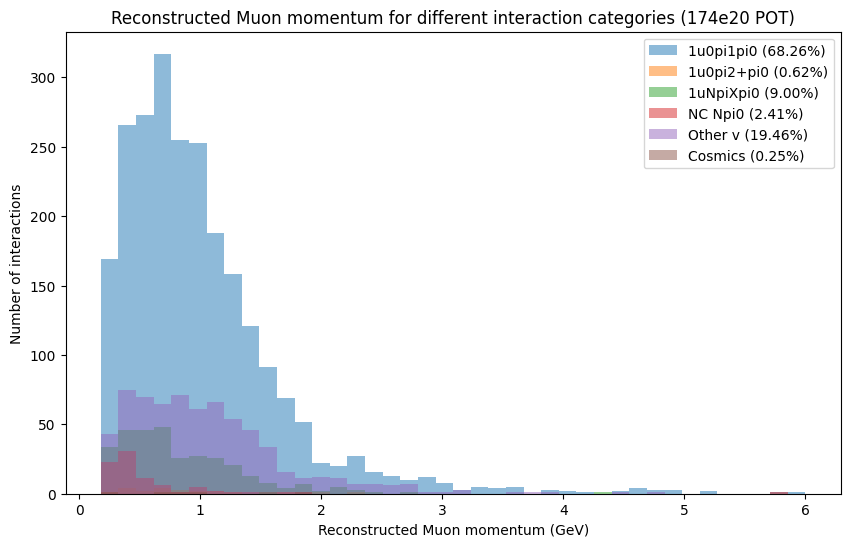

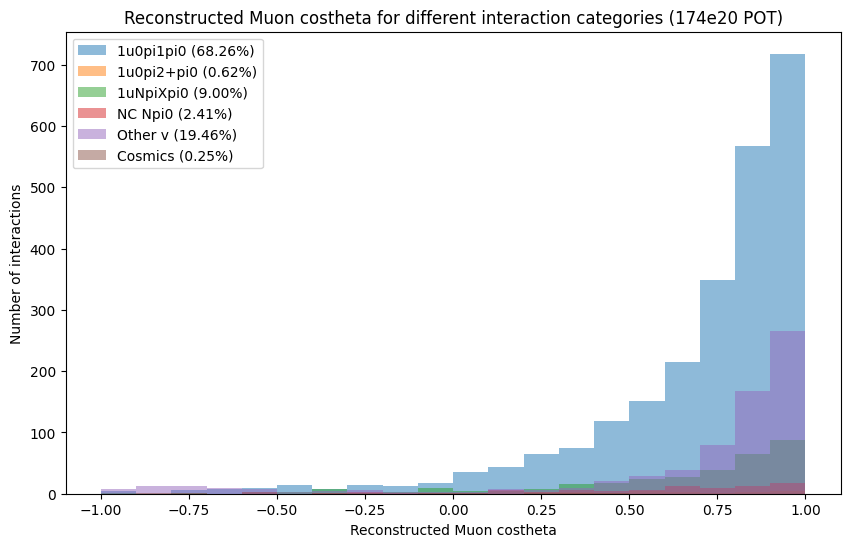

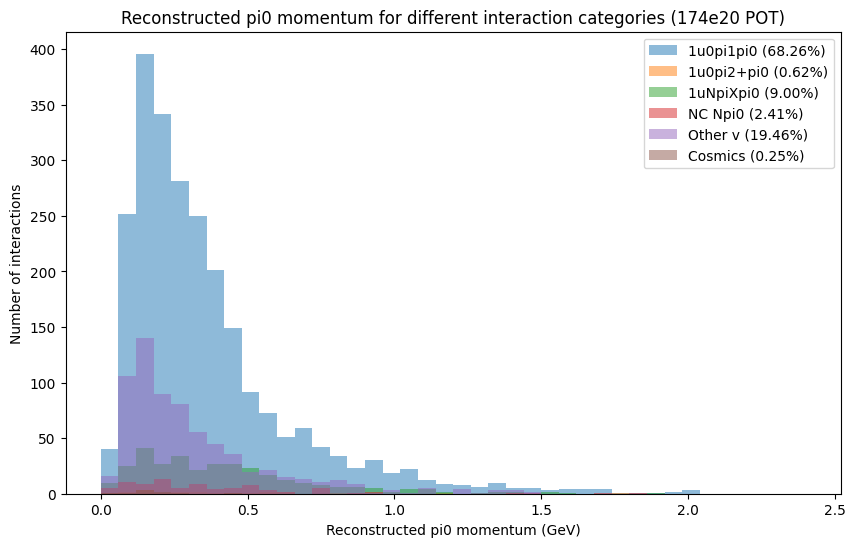

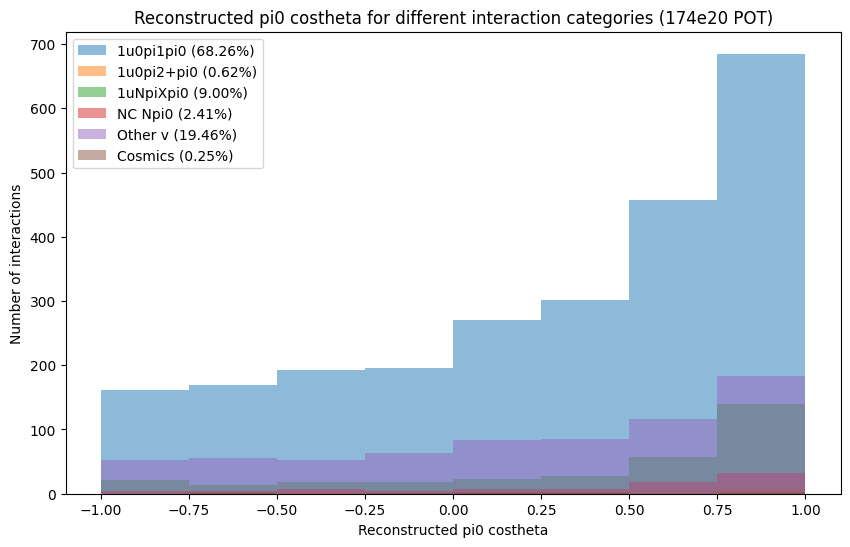

In [7]:
#BNB, input000.flat.root
#yy-shower truth selection 

#Importing relevant libraries
import numpy as np
import uproot
import pandas
import hist
import matplotlib.pyplot as plt

#enable this to see all outputs in a cell
#from IPython.core.interactiveshell import InteractiveShell
#InteractiveShell.ast_node_interactivity = "all"

#Opening the relevant ROOT file and tree
file = uproot.open(
    "e:/FYP/medulla_outputs/2_Shower_Selection_flashcut/NuMI_ccpi0ana_icarus_Jkoh1_initial_selection.root:events/NuMI_simulation/selected_nu"
)

#showing all TBranches
file.keys()

#Combining interaction category variable and reco vertex variables for easier analysis
combinedcategory = file.arrays(["true_category_topology_ccpi0_simple2","reco_muon_p","reco_muon_beam_costheta","reco_pi0_p","reco_pi0_beam_costheta"],library="pd")


#Splitting the interaction category variable into the relevant categories and grouping reco vertex variables according to the categories

#cosmics category: interactions that are not neutrino interactions (true_category_topology_ccpi0_simple2 is NaN)
cosmics_category = combinedcategory[combinedcategory["true_category_topology_ccpi0_simple2"].isna()]
print(f"Number of cosmic interactions and percentage: {len(cosmics_category)} out of {len(combinedcategory)} ({len(cosmics_category)/len(combinedcategory)*100:.2f}%)")

#neutrino 1mu1pi0 category: Neutrino interactions with 1 primary muon, 0 primary charged pions, and 1 primary neutral pion (true_category_topology_ccpi0_simple2 == 0)
neutrino_1mu0pi1pi0_category = combinedcategory[combinedcategory["true_category_topology_ccpi0_simple2"] == 0]
print(f"Number of 1mu0pi1pi0 CC neutrinointeractions and percentage: {len(neutrino_1mu0pi1pi0_category)} out of {len(combinedcategory)} ({len(neutrino_1mu0pi1pi0_category)/len(combinedcategory)*100:.2f}%)")

#neutrino 1mu0pi2pluspi0 category: Neutrino interactions with 1 primary muon, 0 primary charged pions, and 2 or more primary neutral pions (true_category_topology_ccpi0_simple2 == 1)
neutrino_1mu0pi2pluspi0_category = combinedcategory[combinedcategory["true_category_topology_ccpi0_simple2"] == 1]
print(f"Number of 1mu0pi2+pi0 CC neutrino interactions and percentage: {len(neutrino_1mu0pi2pluspi0_category)} out of {len(combinedcategory)} ({len(neutrino_1mu0pi2pluspi0_category)/len(combinedcategory)*100:.2f}%)")

#neutrino 1muNpiXpi0 category: Neutrino interactions with 1 primary muon, N primary charged pions (N>=1), and any number of primary neutral pions (true_category_topology_ccpi0_simple2 == 2)
neutrino_1muNpiXpi0_category = combinedcategory[combinedcategory["true_category_topology_ccpi0_simple2"] == 2]
print(f"Number of 1muNpiXpi0 CC neutrino interactions and percentage: {len(neutrino_1muNpiXpi0_category)} out of {len(combinedcategory)} ({len(neutrino_1muNpiXpi0_category)/len(combinedcategory)*100:.2f}%)")

#neutrino 0muNpi0 category: Neutrino interactions with 0 primary muons, N primary charged pions (N>=0), and any number of primary neutral pions (true_category_topology_ccpi0_simple2 == 3)
neutrino_0muNpi0_category = combinedcategory[combinedcategory["true_category_topology_ccpi0_simple2"] == 3]
print(f"Number of 0muNpi0 NC neutrino interactions and percentage: {len(neutrino_0muNpi0_category)} out of {len(combinedcategory)} ({len(neutrino_0muNpi0_category)/len(combinedcategory)*100:.2f}%)")

#neutrino othernu category: Neutrino interactions that do not fall into the above categories (true_category_topology_ccpi0_simple2 == 4)
neutrino_othernu_category = combinedcategory[combinedcategory["true_category_topology_ccpi0_simple2"] == 4]
print(f"Number of other neutrino interactions and percentage: {len(neutrino_othernu_category)} out of {len(combinedcategory)} ({len(neutrino_othernu_category)/len(combinedcategory)*100:.2f}%)")

#PLotting muon variables ===============================================================================

#Plotting the muon momentum for each category into one histogram
plt.figure(figsize=(10,6))
plt.hist(neutrino_1mu0pi1pi0_category["reco_muon_p"], bins=40, range=(0.18, 6), alpha=0.5, label=f"1u0pi1pi0 ({len(neutrino_1mu0pi1pi0_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(neutrino_1mu0pi2pluspi0_category["reco_muon_p"], bins=40, range=(0.18, 6), alpha=0.5, label=f"1u0pi2+pi0 ({len(neutrino_1mu0pi2pluspi0_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(neutrino_1muNpiXpi0_category["reco_muon_p"], bins=40, range=(0.18, 6), alpha=0.5, label=f"1uNpiXpi0 ({len(neutrino_1muNpiXpi0_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(neutrino_0muNpi0_category["reco_muon_p"], bins=40, range=(0.18, 6), alpha=0.5, label=f"NC Npi0 ({len(neutrino_0muNpi0_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(neutrino_othernu_category["reco_muon_p"], bins=40, range=(0.18, 6), alpha=0.5, label=f"Other v ({len(neutrino_othernu_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(cosmics_category["reco_muon_p"], bins=40, range=(0.18, 6), alpha=0.5, label=f"Cosmics ({len(cosmics_category)/len(combinedcategory)*100:.2f}%)")
plt.legend()
plt.xlabel("Reconstructed Muon momentum (GeV)")
plt.ylabel("Number of interactions")
plt.title(f"Reconstructed Muon momentum for different interaction categories (174e20 POT)")

#Plotting the muon costheta for each category into one histogram
plt.figure(figsize=(10,6))
plt.hist(neutrino_1mu0pi1pi0_category["reco_muon_beam_costheta"], bins=20, range=(-1, 1), alpha=0.5, label=f"1u0pi1pi0 ({len(neutrino_1mu0pi1pi0_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(neutrino_1mu0pi2pluspi0_category["reco_muon_beam_costheta"], bins=20, range=(-1, 1), alpha=0.5, label=f"1u0pi2+pi0 ({len(neutrino_1mu0pi2pluspi0_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(neutrino_1muNpiXpi0_category["reco_muon_beam_costheta"], bins=20, range=(-1, 1), alpha=0.5, label=f"1uNpiXpi0 ({len(neutrino_1muNpiXpi0_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(neutrino_0muNpi0_category["reco_muon_beam_costheta"], bins=20, range=(-1, 1), alpha=0.5, label=f"NC Npi0 ({len(neutrino_0muNpi0_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(neutrino_othernu_category["reco_muon_beam_costheta"], bins=20, range=(-1, 1), alpha=0.5, label=f"Other v ({len(neutrino_othernu_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(cosmics_category["reco_muon_beam_costheta"], bins=20, range=(-1, 1), alpha=0.5, label=f"Cosmics ({len(cosmics_category)/len(combinedcategory)*100:.2f}%)")
plt.legend()
plt.xlabel("Reconstructed Muon costheta")
plt.ylabel("Number of interactions")
plt.title(f"Reconstructed Muon costheta for different interaction categories (174e20 POT)")

#PLotting neutral pion variables ===============================================================================

#Plotting the neutral pion momentum for each category into one histogram
plt.figure(figsize=(10,6))
plt.hist(neutrino_1mu0pi1pi0_category["reco_pi0_p"], bins=40, range=(0, 2.4), alpha=0.5, label=f"1u0pi1pi0 ({len(neutrino_1mu0pi1pi0_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(neutrino_1mu0pi2pluspi0_category["reco_pi0_p"], bins=40, range=(0, 2.4), alpha=0.5, label=f"1u0pi2+pi0 ({len(neutrino_1mu0pi2pluspi0_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(neutrino_1muNpiXpi0_category["reco_pi0_p"], bins=40, range=(0, 2.4), alpha=0.5, label=f"1uNpiXpi0 ({len(neutrino_1muNpiXpi0_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(neutrino_0muNpi0_category["reco_pi0_p"], bins=40, range=(0, 2.4), alpha=0.5, label=f"NC Npi0 ({len(neutrino_0muNpi0_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(neutrino_othernu_category["reco_pi0_p"], bins=40, range=(0, 2.4), alpha=0.5, label=f"Other v ({len(neutrino_othernu_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(cosmics_category["reco_pi0_p"], bins=40, range=(0, 2.4), alpha=0.5, label=f"Cosmics ({len(cosmics_category)/len(combinedcategory)*100:.2f}%)")
plt.legend()
plt.xlabel("Reconstructed pi0 momentum (GeV)")
plt.ylabel("Number of interactions")
plt.title(f"Reconstructed pi0 momentum for different interaction categories (174e20 POT)")

#Plotting the neutral pion costheta for each category into one histogram
plt.figure(figsize=(10,6))
plt.hist(neutrino_1mu0pi1pi0_category["reco_pi0_beam_costheta"], bins=8, range=(-1, 1), alpha=0.5, label=f"1u0pi1pi0 ({len(neutrino_1mu0pi1pi0_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(neutrino_1mu0pi2pluspi0_category["reco_pi0_beam_costheta"], bins=8, range=(-1, 1), alpha=0.5, label=f"1u0pi2+pi0 ({len(neutrino_1mu0pi2pluspi0_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(neutrino_1muNpiXpi0_category["reco_pi0_beam_costheta"], bins=8, range=(-1, 1), alpha=0.5, label=f"1uNpiXpi0 ({len(neutrino_1muNpiXpi0_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(neutrino_0muNpi0_category["reco_pi0_beam_costheta"], bins=8, range=(-1, 1), alpha=0.5, label=f"NC Npi0 ({len(neutrino_0muNpi0_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(neutrino_othernu_category["reco_pi0_beam_costheta"], bins=8, range=(-1, 1), alpha=0.5, label=f"Other v ({len(neutrino_othernu_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(cosmics_category["reco_pi0_beam_costheta"], bins=8, range=(-1, 1), alpha=0.5, label=f"Cosmics ({len(cosmics_category)/len(combinedcategory)*100:.2f}%)")
plt.legend()
plt.xlabel("Reconstructed pi0 costheta")
plt.ylabel("Number of interactions")
plt.title(f"Reconstructed pi0 costheta for different interaction categories (174e20 POT)")






<h2 style="font-size: 24px;">extra. analysis of other neutrino interactions category</h2>

In [11]:
#BNB, input000.flat.root
#yy-shower truth selection 

#Importing relevant libraries
import numpy as np
import uproot
import pandas
import hist
import matplotlib.pyplot as plt

#enable this to see all outputs in a cell
#from IPython.core.interactiveshell import InteractiveShell
#InteractiveShell.ast_node_interactivity = "all"

#Opening the relevant ROOT file and tree
file = uproot.open(
    "e:/FYP/medulla_outputs/2_Shower_Selection_flashcut/NuMI_ccpi0ana_icarus_Jkoh1_initial_selection_extra_2.root:events/NuMI_simulation/selected_nu"
)

#showing all TBranches
file.keys()

#Combining interaction category variable and reco particle multiplicity variables for easier analysis
combinedcategory = file.arrays(["true_category_topology_ccpi0_simple2"
                                ,"true_photon_multiplicity"
                                ,"true_muon_multiplicity"
                                ,"true_pion_multiplicity"
                                ,"true_pi0_multiplicity"
                                ,"true_vertex_x"
                                ,"true_vertex_y"
                                ,"true_vertex_z"
                                ,"true_fiducial_cut"
                                ,"true_cc"
                                ,"true_pdg"],library="pd")


#neutrino othernu category: Neutrino interactions that do not fall into the above categories (true_category_topology_ccpi0_simple2 == 4)
neutrino_othernu_category = combinedcategory[combinedcategory["true_category_topology_ccpi0_simple2"] == 4]
print(f"Number of other neutrino interactions and percentage: {len(neutrino_othernu_category)} out of {len(combinedcategory)} ({len(neutrino_othernu_category)/len(combinedcategory)*100:.2f}%)")

#Further spltting the othernu category into their common interaction types using the reco particle multiplicity variables

#Finding the common interaction types in the othernu category using the reco particle multiplicity variables
cols = [
    "true_photon_multiplicity",
    "true_muon_multiplicity",
    "true_pion_multiplicity",
    "true_pi0_multiplicity",
    "true_fiducial_cut",
    "true_cc",
    "true_pdg"
]

# Group identical rows and count
group_counts = (
    neutrino_othernu_category.groupby(cols)
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

#caluclating the percentage of the 5 most common interaction type in the othernu category over the total number of interactions in the othernu category
total_othernu = len(neutrino_othernu_category)
group_counts["percentage"] = group_counts["count"] / total_othernu * 100
print(group_counts[["true_photon_multiplicity", "true_muon_multiplicity", "true_pion_multiplicity", "true_pi0_multiplicity","true_fiducial_cut","true_cc","true_pdg", "count", "percentage"]].to_string(index=False))

#plotting the vertex position for the most common interaction type in the othernu category using the true vertex position variables
most_common_othernu = group_counts.iloc[0]
most_common_othernu_category = neutrino_othernu_category[
    (neutrino_othernu_category["true_photon_multiplicity"] == most_common_othernu["true_photon_multiplicity"]) &
    (neutrino_othernu_category["true_muon_multiplicity"] == most_common_othernu["true_muon_multiplicity"]) &
    (neutrino_othernu_category["true_pion_multiplicity"] == most_common_othernu["true_pion_multiplicity"]) &
    (neutrino_othernu_category["true_pi0_multiplicity"] == most_common_othernu["true_pi0_multiplicity"]) &
    (neutrino_othernu_category["true_fiducial_cut"] == most_common_othernu["true_fiducial_cut"]) &
    (neutrino_othernu_category["true_cc"] == most_common_othernu["true_cc"]) &
    (neutrino_othernu_category["true_pdg"] == most_common_othernu["true_pdg"])
]

#calculating number of antineutrino interactions in the othernu category using the true pdg variable
num_antinues_othernu = len(neutrino_othernu_category[neutrino_othernu_category["true_pdg"] == -14])
print(f"Number of antineutrino interactions in the othernu category: {num_antinues_othernu} out of {len(neutrino_othernu_category)} ({num_antinues_othernu/len(neutrino_othernu_category)*100:.2f}%)")  

#removing antineutrino interactions from the most common othernu category
no_anti_neutrinos_full = combinedcategory[combinedcategory["true_pdg"] != -14]
no_anti_neutrinos_other = neutrino_othernu_category[neutrino_othernu_category["true_pdg"] != -14]   

#recalculating percentage of all selected reconstructed interactions that belong in other neutrino category after removing antineutrino interactions
total_selected_interactions = len(no_anti_neutrinos_full)
total_othernu_no_antinues = len(no_anti_neutrinos_other)
percentage_othernu_no_antinues = total_othernu_no_antinues / total_selected_interactions * 100
print(f"Number of other neutrino interactions after removing antineutrinos and percentage: {total_othernu_no_antinues} out of {total_selected_interactions} ({percentage_othernu_no_antinues:.2f}%)")







Number of other neutrino interactions and percentage: 694 out of 3566 (19.46%)
 true_photon_multiplicity  true_muon_multiplicity  true_pion_multiplicity  true_pi0_multiplicity  true_fiducial_cut  true_cc  true_pdg  count  percentage
                      2.0                     1.0                     0.0                    1.0                1.0      1.0     -14.0    420   60.518732
                      2.0                     1.0                     1.0                    1.0                1.0      1.0     -14.0     46    6.628242
                      0.0                     1.0                     0.0                    0.0                1.0      1.0      14.0     32    4.610951
                      0.0                     1.0                     0.0                    0.0                1.0      1.0     -14.0     28    4.034582
                      2.0                     1.0                     0.0                    1.0                0.0      1.0      14.0     25    3.6023

<h2 style="font-size: 24px;">1.5. Lane TOML file analysis</h2>

Number of cosmic interactions and percentage: 0 out of 4369 (0.00%)
Number of 1mu0pi1pi0 CC neutrinointeractions and percentage: 3881 out of 4369 (88.83%)
Number of 1mu0pi2+pi0 CC neutrino interactions and percentage: 22 out of 4369 (0.50%)
Number of 1muNpiXpi0 CC neutrino interactions and percentage: 233 out of 4369 (5.33%)
Number of 0muNpi0 NC neutrino interactions and percentage: 54 out of 4369 (1.24%)
Number of other neutrino interactions and percentage: 179 out of 4369 (4.10%)


Text(0.5, 1.0, 'Reconstructed pi0 mass distribution for different interaction categories (1.74e+20 POT)')

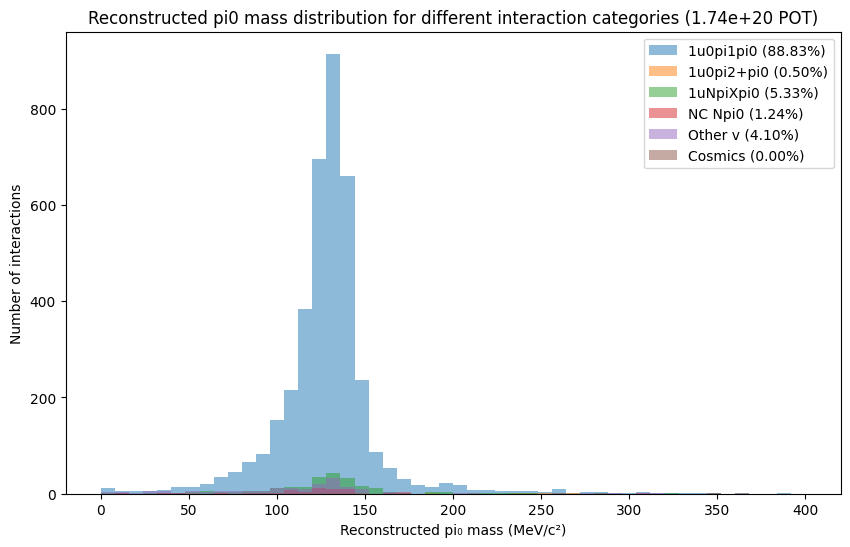

In [1]:
#BNB, input000.flat.root
#yy-shower truth selection 

#Importing relevant libraries
import numpy as np
import uproot
import pandas
import hist
import matplotlib.pyplot as plt

#enable this to see all outputs in a cell
#from IPython.core.interactiveshell import InteractiveShell
#InteractiveShell.ast_node_interactivity = "all"

#Opening the relevant ROOT file and tree
file = uproot.open(
    "e:/FYP/medulla_outputs/2_Shower_Selection_flashcut/ccpi0ana_icarus.root:events/cv/selected_nu"
)

#showing all TBranches
file.keys()

#Purity analysis
# --------------------------------------------------------------------------------

#Combining interaction category variable and pi0 mass variable for easier analysis
combinedcategory = file.arrays(["true_category_topology_ccpi0_simple2","reco_pi0_mass"],library="pd")

#Removing interactions with pi0 mass greater than 400 MeV/c^2 as they are not relevant for our analysis and are likely background interactions
combinedcategory = combinedcategory[combinedcategory["reco_pi0_mass"] < 400]
POT = 1.74e20

#Splitting the interaction category variable into the relevant categories

#cosmics category: interactions that are not neutrino interactions (true_category_topology_ccpi0_simple2 is NaN)
cosmics_category = combinedcategory[combinedcategory["true_category_topology_ccpi0_simple2"].isna()]
print(f"Number of cosmic interactions and percentage: {len(cosmics_category)} out of {len(combinedcategory)} ({len(cosmics_category)/len(combinedcategory)*100:.2f}%)")

#neutrino 1mu1pi0 category: Neutrino interactions with 1 primary muon, 0 primary charged pions, and 1 primary neutral pion (true_category_topology_ccpi0_simple2 == 0)
neutrino_1mu0pi1pi0_category = combinedcategory[combinedcategory["true_category_topology_ccpi0_simple2"] == 0]
print(f"Number of 1mu0pi1pi0 CC neutrinointeractions and percentage: {len(neutrino_1mu0pi1pi0_category)} out of {len(combinedcategory)} ({len(neutrino_1mu0pi1pi0_category)/len(combinedcategory)*100:.2f}%)")

#neutrino 1mu0pi2pluspi0 category: Neutrino interactions with 1 primary muon, 0 primary charged pions, and 2 or more primary neutral pions (true_category_topology_ccpi0_simple2 == 1)
neutrino_1mu0pi2pluspi0_category = combinedcategory[combinedcategory["true_category_topology_ccpi0_simple2"] == 1]
print(f"Number of 1mu0pi2+pi0 CC neutrino interactions and percentage: {len(neutrino_1mu0pi2pluspi0_category)} out of {len(combinedcategory)} ({len(neutrino_1mu0pi2pluspi0_category)/len(combinedcategory)*100:.2f}%)")

#neutrino 1muNpiXpi0 category: Neutrino interactions with 1 primary muon, N primary charged pions (N>=1), and any number of primary neutral pions (true_category_topology_ccpi0_simple2 == 2)
neutrino_1muNpiXpi0_category = combinedcategory[combinedcategory["true_category_topology_ccpi0_simple2"] == 2]
print(f"Number of 1muNpiXpi0 CC neutrino interactions and percentage: {len(neutrino_1muNpiXpi0_category)} out of {len(combinedcategory)} ({len(neutrino_1muNpiXpi0_category)/len(combinedcategory)*100:.2f}%)")

#neutrino 0muNpi0 category: Neutrino interactions with 0 primary muons, N primary charged pions (N>=0), and any number of primary neutral pions (true_category_topology_ccpi0_simple2 == 3)
neutrino_0muNpi0_category = combinedcategory[combinedcategory["true_category_topology_ccpi0_simple2"] == 3]
print(f"Number of 0muNpi0 NC neutrino interactions and percentage: {len(neutrino_0muNpi0_category)} out of {len(combinedcategory)} ({len(neutrino_0muNpi0_category)/len(combinedcategory)*100:.2f}%)")

#neutrino othernu category: Neutrino interactions that do not fall into the above categories (true_category_topology_ccpi0_simple2 == 4)
neutrino_othernu_category = combinedcategory[combinedcategory["true_category_topology_ccpi0_simple2"] == 4]
print(f"Number of other neutrino interactions and percentage: {len(neutrino_othernu_category)} out of {len(combinedcategory)} ({len(neutrino_othernu_category)/len(combinedcategory)*100:.2f}%)")

#Plotting the pi0 mass distribution for each category into one histogram
plt.figure(figsize=(10,6))
plt.hist(neutrino_1mu0pi1pi0_category["reco_pi0_mass"], bins=50, range=(0, 400), alpha=0.5, label=f"1u0pi1pi0 ({len(neutrino_1mu0pi1pi0_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(neutrino_1mu0pi2pluspi0_category["reco_pi0_mass"], bins=50, range=(0, 400), alpha=0.5, label=f"1u0pi2+pi0 ({len(neutrino_1mu0pi2pluspi0_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(neutrino_1muNpiXpi0_category["reco_pi0_mass"], bins=50, range=(0, 400), alpha=0.5, label=f"1uNpiXpi0 ({len(neutrino_1muNpiXpi0_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(neutrino_0muNpi0_category["reco_pi0_mass"], bins=50, range=(0, 400), alpha=0.5, label=f"NC Npi0 ({len(neutrino_0muNpi0_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(neutrino_othernu_category["reco_pi0_mass"], bins=50, range=(0, 400), alpha=0.5, label=f"Other v ({len(neutrino_othernu_category)/len(combinedcategory)*100:.2f}%)")
plt.hist(cosmics_category["reco_pi0_mass"], bins=50, range=(0, 400), alpha=0.5, label=f"Cosmics ({len(cosmics_category)/len(combinedcategory)*100:.2f}%)")
plt.legend()
plt.xlabel("Reconstructed pi₀ mass (MeV/c²)")
plt.ylabel("Number of interactions")
plt.title(f"Reconstructed pi0 mass distribution for different interaction categories ({POT} POT)")